# Final Analysis: Dynamic Temperature Story Generation
**Group 17 — NLP Final Project**

---

## Experiment Setup
- **Generator**: Qwen/Qwen2.5-1.5B-Instruct (instruct, fp16, top_p=1.0, top_k=0)
- **Stories**: 30 prompts × 30 shadow stories × 11 schedules = **9,900 stories**
- **Generation**: 7 chunks × 70 tokens/chunk ≈ 490 tokens/story
- **Schedules**: 7 fixed-temperature baselines + 4 named dynamic schedules

## Metrics
All metrics are computed per story, averaged per prompt (across 30 shadows), then per schedule (across 30 prompts).

| Metric | Method | Reference |
|---|---|---|
| **N-gram Diversity** | Distinct-n for n∈{1..5} | Ismaylzade et al. (2024) |
| **Semantic Diversity** | Inverse homogenization (avg pairwise 1−cos sim) | Padmakumar & He (2023) |
| **Novelty** | 2·\|D(story) − D(corpus)\| using dominant term embeddings | Karampiperis et al. (2014) |
| **Surprise** | Avg semantic shift between consecutive sentences | Karampiperis et al. (2014) |
| **Complexity** | Lexical + syntactic complexity features | Ismaylzade et al. (2024); Flesch (1940) |
| **Coherence** | Conditional log-likelihood via OPT-125M and OPT-1.3B | Su & Collier (2022) |

Metric functions mirror the implementation in [Ismaylzade et al. creative-story-gen](https://github.com/mismayil/creative-story-gen/blob/main/src/metrics.py).

# Data & Metrics Reference

---

## Input Data Structure

Each schedule has its own directory under `results_final/`:
```
results_final/
  Qwen_Qwen2.5-1.5B-Instruct_<schedule_name>/
    stories.jsonl            ← raw generated stories
    stories_opt_scored.jsonl ← stories + OPT coherence scores
```

The notebook reads from `stories_opt_scored.jsonl` if available, else falls back to `stories.jsonl`.

Each line is a JSON record with the following fields:

| Field | Type | Description |
|---|---|---|
| `prompt_id` | int | Index of the writing prompt (0–29, 30 prompts total) |
| `shadow_id` | int | Independent sample index (0–29, 30 shadows per prompt) |
| `model` | str | Generator model name |
| `schedule` | str | Schedule name (e.g. `fixed_temperature_1.0`, `increasing`) |
| `temperatures` | List[float] | Temperature value per chunk (length = n_chunks = 7) |
| `prompt` | str | The writing prompt text |
| `tokens_per_chunk` | int | Max tokens generated per chunk (70) |
| `chunk_texts` | List[str] | Generated text for each of the 7 chunks |
| `story` | str | Full story = chunks joined by space |
| `chunk_entropies` | List[List[float]] | Per-token entropy (nats) for each chunk |
| `chunk_nucleus_sizes` | List[List[int]] | 90%-nucleus size per token per chunk |
| `coherence_opt_125m` | float | OPT-125M coherence score (mean token log-prob) |
| `coherence_opt_1_3b` | float | OPT-1.3B coherence score (mean token log-prob) |

**Experiment scale:** 30 prompts × 30 shadows × 11 schedules = **9,900 stories**
- 7 fixed-temperature schedules: `fixed_temperature_{0.01, 0.334, 0.667, 1.0, 1.334, 1.667, 2.0}`
- 4 dynamic schedules: `increasing`, `decreasing`, `valley`, `peak`

---

## Metrics

All story-level metrics are averaged first across shadows (per prompt), then across prompts (per schedule).

---

### 1. N-gram Diversity  `ngram_1` … `ngram_5`
**Reference:** Li et al. (2016) Distinct-n; Ismaylzade et al. (2024)

$$\text{diversity}_n = \frac{|\text{unique } n\text{-grams}|}{|\text{total } n\text{-grams}|}$$

- Computed for n ∈ {1, 2, 3, 4, 5}
- Stopwords kept, no lemmatization (surface-form repetition)
- Raw range: [0, 1] → **scaled to [0, 2]** (×2) for comparability with other metrics
- Higher = more lexically varied

---

### 2. Semantic Diversity  `sem_diversity`
**Reference:** Padmakumar & He (2023); Ismaylzade et al. (2024)

$$\text{inv\_hom}(s) = \frac{1}{|S_t|-1} \sum_{s' \neq s} \text{semdis}(s, s')$$

- Computed **within prompt**: each story is compared to the other 29 shadows on the same prompt
- `semdis(a, b) = 1 − cosine_similarity(embed(a), embed(b))` using `thenlper/gte-large`
- Range: [0, 2] (cosine distance)
- Higher = story is semantically distinct from its prompt-siblings

---

### 3. Novelty  `novelty`
**Reference:** Karampiperis et al. (2014); Ismaylzade et al. (2024)

$$D(S) = \frac{\sum_{i \neq j} \text{semdis}(T_i, T_j)}{|T|}$$
$$\text{Nov}(S) = 2 \cdot |D(S) - D(S_G)|$$

- $T$ = top-25 most frequent lemmatized content words of story $S$ (dominant terms)
- $S_G$ = corpus of all 330 stories for the same prompt (across all schedules)
- $D(S_G)$ uses the top-25 globally dominant terms of that prompt corpus
- **Methodological note:** paper uses a global corpus across all stories; we use per-prompt corpus to control for topic variation
- Range: [0, 2]
- Higher = story's vocabulary is semantically more spread out than the prompt average

---

### 4. Surprise  `surprise`
**Reference:** Karampiperis et al. (2014); Ismaylzade et al. (2024)

$$\text{Sur}(S) = \frac{2}{|F|-1} \sum_{i=2}^{|F|} |D(F_i) - D(F_{i-1})|$$

- $F_i$ = sentence $i$ of the story; $D(F_i)$ = avg pairwise semantic distance of its dominant terms
- Measures semantic jumps between consecutive sentences
- Range: [0, 2]
- Higher = story makes larger semantic leaps as it unfolds

---

### 5. Complexity
**Reference:** Ismaylzade et al. (2024); Flesch (1940)

| Column | Formula / Description |
|---|---|
| `unique_words` | Count of unique lemmatized content words (stopwords removed) |
| `avg_word_len` | Mean character length of non-punctuation tokens |
| `avg_sent_len` | Mean words per sentence |
| `flesch_ease` | $206.835 - 1.015 \frac{W}{S} - 84.6 \frac{Syl}{W}$ — higher = more readable |
| `flesch_kincaid` | $0.39 \frac{W}{S} + 11.8 \frac{Syl}{W} - 15.59$ — higher = harder |
| `noun_ratio` | NOUN tokens / all non-punctuation tokens |
| `adj_ratio` | ADJ tokens / all non-punctuation tokens |
| `verb_ratio` | VERB tokens / all non-punctuation tokens |
| `adv_ratio` | ADV tokens / all non-punctuation tokens |
| `avg_dep_path_len` | Mean dependency path length per token (syntactic depth) |

POS tags and dependency parse from `spacy en_core_web_sm`.

---

### 6. Coherence  `coherence_125m`, `coherence_1_3b`
**Reference:** Su & Collier (2022); Ismaylzade et al. (2024)

$$\text{coherence}(S | P) = \frac{1}{|\hat{x}|} \sum_i \log p_M(\hat{x}_i \mid [P \oplus \hat{x}_{<i}])$$

- $P$ = prompt, $\hat{x}$ = story, $M$ = OPT evaluator model (separate from generator)
- Context = `[BOS + prompt]`, prediction = story tokens
- Two model sizes: `facebook/opt-125m` and `facebook/opt-1.3b`
- Values are negative log-probabilities — **less negative = more coherent**
- Higher (closer to 0) = better

---

## Adapting to New Data

To run this notebook on different data:
1. Update `RESULTS_DIR` and `MODEL_NAME` in the **Configuration** cell
2. Ensure each schedule directory contains `stories.jsonl` (or `stories_opt_scored.jsonl` for coherence)
3. Each record must have at minimum: `prompt_id`, `shadow_id`, `schedule`, `prompt`, `story`
4. Delete `analysis_cache/` before re-running to force metric recomputation
5. If coherence keys differ from `coherence_opt_125m`/`coherence_opt_1_3b`, update the key names in the **Build Master DataFrame** cell

In [1]:
import os, sys, json, pickle, warnings, re
from pathlib import Path
from collections import Counter
from statistics import mean
from typing import List, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

ROOT = Path(os.path.abspath('..')).resolve()
sys.path.insert(0, str(ROOT))

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
pd.set_option('display.float_format', '{:.4f}'.format)
print('Root:', ROOT)

Root: /Users/ishaicahila/Documents/תואר/NLP/nlp_final_project


/Users/ishaicahila/Documents/תואר/NLP/nlp_final_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
RESULTS_DIR = ROOT / 'results_final'
CACHE_DIR   = ROOT / 'analysis_cache'
CACHE_DIR.mkdir(exist_ok=True)

# ── Generator model ────────────────────────────────────────────────────────────
MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
SAFE_MODEL = MODEL_NAME.replace('/', '_')

# ── Schedules ─────────────────────────────────────────────────────────────────
FIXED_TEMPS      = [0.01, 0.334, 0.667, 1.0, 1.334, 1.667, 2.0]
# FIXED_TEMPS      = [ 0.667, 1.0, 1.334, 1.667, 2.0]
FIXED_SCHEDULES  = [f'fixed_temperature_{t}' for t in FIXED_TEMPS]
DYNAMIC_SCHEDULES = ['increasing', 'decreasing', 'valley', 'peak']
# DYNAMIC_SCHEDULES = ['increasing', 'decreasing', 'peak']
ALL_SCHEDULES    = FIXED_SCHEDULES + DYNAMIC_SCHEDULES

# ── Human-readable schedule labels ────────────────────────────────────────────
SCHED_LABELS = {s: f'T={t}' for s, t in zip(FIXED_SCHEDULES, FIXED_TEMPS)}
SCHED_LABELS.update({s: s for s in DYNAMIC_SCHEDULES})

# ── Embedding model (gte-large, as used in Ismaylzade et al.) ─────────────────
EMB_MODEL_NAME = 'thenlper/gte-large'

# ── Color palettes (consistent across all plots) ──────────────────────────────
FIXED_PALETTE   = sns.color_palette('Blues',  n_colors=len(FIXED_SCHEDULES) + 2)[2:]
DYNAMIC_PALETTE = sns.color_palette('Set2',   n_colors=len(DYNAMIC_SCHEDULES))
ALL_PALETTE     = FIXED_PALETTE + DYNAMIC_PALETTE
COLOR_MAP       = dict(zip(ALL_SCHEDULES, ALL_PALETTE))

N_PROMPTS = 30
N_SHADOWS = 30
print('Configuration loaded.')
print(f'Fixed schedules   ({len(FIXED_SCHEDULES)}):', FIXED_SCHEDULES)
print(f'Dynamic schedules ({len(DYNAMIC_SCHEDULES)}):', DYNAMIC_SCHEDULES)

Configuration loaded.
Fixed schedules   (7): ['fixed_temperature_0.01', 'fixed_temperature_0.334', 'fixed_temperature_0.667', 'fixed_temperature_1.0', 'fixed_temperature_1.334', 'fixed_temperature_1.667', 'fixed_temperature_2.0']
Dynamic schedules (4): ['increasing', 'decreasing', 'valley', 'peak']


## 1. Load Data

In [5]:
def load_schedule_stories(schedule_name: str) -> List[Dict]:
    """
    Load stories for one schedule.
    Prefers stories_opt_scored.jsonl (has coherence keys) over stories.jsonl.
    """
    base = RESULTS_DIR / f'{SAFE_MODEL}_{schedule_name}'
    for fname in ('stories_opt_scored.jsonl', 'stories.jsonl'):
        path = base / fname
        if path.exists():
            stories = []
            with open(path) as f:
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    try:
                        stories.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass
            return stories
    return []


print('Loading stories from results_final/ ...')
all_stories: Dict[str, List[Dict]] = {}
for sched in ALL_SCHEDULES:
    stories = load_schedule_stories(sched)
    all_stories[sched] = stories
    has_coh = stories and 'coherence_opt_1_3b' in stories[0]
    print(f'  {SCHED_LABELS[sched]:18s}: {len(stories):4d} stories | coherence scored: {has_coh}')

AVAILABLE_SCHEDULES = [s for s in ALL_SCHEDULES if all_stories[s]]
print(f'\nAvailable: {len(AVAILABLE_SCHEDULES)}/{len(ALL_SCHEDULES)} schedules')

Loading stories from results_final/ ...
  T=0.01            :  900 stories | coherence scored: True
  T=0.334           :  349 stories | coherence scored: True
  T=0.667           :  900 stories | coherence scored: True
  T=1.0             :  900 stories | coherence scored: True
  T=1.334           :  900 stories | coherence scored: True
  T=1.667           :  900 stories | coherence scored: True
  T=2.0             :  900 stories | coherence scored: True
  increasing        :  900 stories | coherence scored: True
  decreasing        :  900 stories | coherence scored: True
  valley            :  900 stories | coherence scored: True
  peak              :  900 stories | coherence scored: True

Available: 11/11 schedules


## 2. Metric Functions

All functions mirror [Ismaylzade et al. metrics.py](https://github.com/mismayil/creative-story-gen/blob/main/src/metrics.py) exactly.

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# Model singletons — loaded once and reused
# ─────────────────────────────────────────────────────────────────────────────
_spacy_engines: Dict = {}
_emb_model = None
_emb_cache: Dict[str, np.ndarray] = {}


def get_spacy_engine(include_syllables: bool = False):
    """Load (or return cached) spaCy en_core_web_sm pipeline."""
    key = include_syllables
    if key not in _spacy_engines:
        import spacy
        print(f'Loading spaCy en_core_web_sm (syllables={include_syllables}) ...')
        engine = spacy.load('en_core_web_sm')
        if include_syllables:
            engine.add_pipe('syllables', after='tagger')
        _spacy_engines[key] = engine
    return _spacy_engines[key]


def get_emb_model():
    """Load (or return cached) gte-large sentence transformer."""
    global _emb_model
    if _emb_model is None:
        from sentence_transformers import SentenceTransformer
        print(f'Loading {EMB_MODEL_NAME} ...')
        _emb_model = SentenceTransformer(EMB_MODEL_NAME)
        print('Embedding model loaded.')
    return _emb_model


def get_embedding(text: str) -> np.ndarray:
    """Cached single-text embedding via gte-large."""
    if text not in _emb_cache:
        _emb_cache[text] = get_emb_model().encode(text, show_progress_bar=False)
    return _emb_cache[text]


def compute_sem_dis(emb1: np.ndarray, emb2: np.ndarray) -> float:
    """Semantic distance = 1 - cosine_similarity."""
    from sentence_transformers.util import cos_sim
    return float(1 - cos_sim(emb1, emb2))


# ─────────────────────────────────────────────────────────────────────────────
# Text helpers
# ─────────────────────────────────────────────────────────────────────────────

def get_sentences(text: str) -> List[str]:
    return [sent.text for sent in get_spacy_engine()(text).sents]


def get_words(text: str, lower=True, remove_punct=True, remove_stopwords=True,
              lemmatize=True, unique=True, dominant_k=None) -> List[str]:
    """Return (optionally filtered) word list from text."""
    doc = get_spacy_engine()(text)
    tokens = list(doc)
    if remove_punct:      tokens = [t for t in tokens if not t.is_punct]
    if remove_stopwords:  tokens = [t for t in tokens if not t.is_stop]
    words = [t.lemma_ if lemmatize else t.text for t in tokens]
    if lower: words = [w.lower() for w in words]
    if dominant_k and dominant_k < len(words):
        return [w for w, _ in Counter(words).most_common(dominant_k)]
    return list(set(words)) if unique else words


# ─────────────────────────────────────────────────────────────────────────────
# 1. N-gram Diversity
#    Reference: Ismaylzade et al. (2024); Li et al. (2016) Distinct-n
# ─────────────────────────────────────────────────────────────────────────────

def compute_n_gram_diversity(text: str, max_n: int = 5) -> List[float]:
    """
    Distinct-n lexical diversity for n in {1 .. max_n}.

    diversity_n = |unique n-grams| / |total n-grams|

    Stopwords are kept (diversity should reflect all word choices).
    Returns a list of max_n floats in [0, 1].
    """
    words = get_words(text, lower=True, remove_punct=True,
                      remove_stopwords=False, lemmatize=False, unique=False)
    result = []
    for n in range(1, max_n + 1):
        grams = [tuple(words[i:i+n]) for i in range(len(words) - n + 1)]
        result.append(len(set(grams)) / len(grams) if grams else 0.0)
    return result


# ─────────────────────────────────────────────────────────────────────────────
# 2. Semantic Diversity — Inverse Homogenization Score
#    Reference: Ismaylzade et al. (2024); Padmakumar & He (2023)
# ─────────────────────────────────────────────────────────────────────────────

def compute_inverse_homogenization(texts: List[str]) -> List[float]:
    """
    For a set of stories written on the same prompt (St), compute each story's
    average semantic distance to all other stories in the set:

        inv_hom(s | t) = 1/(|St|-1) * sum_{s'!=s} semdis(s, s')

    semdis = 1 - cosine_similarity on gte-large sentence embeddings.
    Higher = more semantically distinct from peers = more diverse.
    Stories are batch-encoded for efficiency.
    """
    model = get_emb_model()
    embs = model.encode(texts, show_progress_bar=False, batch_size=32)
    scores = []
    for i in range(len(embs)):
        dists = [compute_sem_dis(embs[i], embs[j])
                 for j in range(len(embs)) if j != i]
        scores.append(mean(dists) if dists else 0.0)
    return scores


# ─────────────────────────────────────────────────────────────────────────────
# 3. Novelty
#    Reference: Ismaylzade et al. (2024); Karampiperis et al. (2014)
#
# Dominant terms = top-25 most frequent lemmatized content words (by term
# frequency).  D(SG) uses the top-25 globally across ALL stories; D(S) uses
# the top-25 within each individual story.  The global corpus word frequencies
# are built by aggregating per-story word counts — no giant string join, so
# spaCy stays fast.  D(SG) is computed once and reused for all stories.
# ─────────────────────────────────────────────────────────────────────────────

DOMINANT_K = 30  # top-k dominant terms (Karampiperis et al., 2014)


def _pairwise_sem_dis(words: List[str]) -> float:
    """Mean pairwise semantic distance between a list of words."""
    if len(words) <= 1:
        return 0.0
    embs = [get_embedding(w) for w in words]
    dists = [compute_sem_dis(embs[i], embs[j])
             for i in range(len(embs)) for j in range(len(embs)) if i != j]
    return mean(dists) if dists else 0.0


def compute_novelty(texts: List[str]) -> List[float]:
    """
    Story novelty (Karampiperis et al., 2014; Ismaylzade et al., 2024):

        D(S)  = avg pairwise semdis of top-DOMINANT_K content words in story S
        D(SG) = avg pairwise semdis of top-DOMINANT_K content words globally
        Nov(S) = 2 * |D(S) - D(SG)|  ∈ [0, 2]

    D(SG) uses the global corpus (all texts passed in) and is computed once.
    Word frequencies are aggregated per-story to avoid running spaCy on a
    single giant joined string.
    """
    # Build global term-frequency counter from per-story word lists
    global_counter: Counter = Counter()
    story_words: List[List[str]] = []
    for text in texts:
        words = get_words(text, unique=False)   # all occurrences for TF count
        global_counter.update(words)
        story_words.append(words)

    # Top-25 globally dominant terms → D(SG)
    corpus_dominant = [w for w, _ in global_counter.most_common(DOMINANT_K)]
    d_corpus = _pairwise_sem_dis(corpus_dominant)

    # Per-story top-25 dominant terms → D(S)
    scores = []
    for words in story_words:
        top_k = [w for w, _ in Counter(words).most_common(DOMINANT_K)]
        d_story = _pairwise_sem_dis(top_k)
        scores.append(2 * abs(d_story - d_corpus))
    return scores


# ─────────────────────────────────────────────────────────────────────────────
# 4. Surprise
#    Reference: Ismaylzade et al. (2024); Karampiperis et al. (2014)
# ─────────────────────────────────────────────────────────────────────────────

def compute_surprise(text: str) -> float:
    """
    Average semantic distance between consecutive sentences, normalised to [0, 2]:

        Sur(S) = (2 / (|F|-1)) * sum_{i=2}^{|F|} |D(F_i) - D(F_{i-1})|

    D(F_i) = avg pairwise word-level semantic distance of sentence F_i.
    High surprise = large semantic jumps as the story unfolds.
    """
    sentences = get_sentences(text)
    if len(sentences) <= 1:
        return 0.0
    sent_d = [_pairwise_sem_dis(get_words(s)) for s in sentences]
    raw = [abs(sent_d[i] - sent_d[i-1]) for i in range(1, len(sent_d))]
    return (2 / len(raw)) * sum(raw) if raw else 0.0


# ─────────────────────────────────────────────────────────────────────────────
# 5. Complexity
#    Reference: Ismaylzade et al. (2024); Flesch (1940)
# ─────────────────────────────────────────────────────────────────────────────

def compute_complexity(text: str) -> Dict[str, float]:
    """
    Lexical and syntactic complexity metrics.

    Lexical:
      unique_words    -- count of unique lemmatized content words
      avg_word_len    -- mean character length of non-punctuation tokens
      avg_sent_len    -- mean words per sentence
      flesch_ease     -- Flesch Reading Ease (Flesch 1940); higher = easier
      flesch_kincaid  -- Flesch-Kincaid Grade Level; higher = more complex

    Syntactic (POS ratios over non-punctuation tokens):
      noun_ratio, adj_ratio, verb_ratio, adv_ratio

    Syntactic (dependency):
      avg_dep_path_len -- mean dependency path length per token across the story
    """
    doc     = get_spacy_engine()(text)
    doc_syl = get_spacy_engine(include_syllables=True)(text)

    sentences  = list(doc.sents)
    all_tokens = [t for t in doc if not t.is_punct]

    # Lexical
    unique_words = len(set(t.lemma_.lower() for t in all_tokens if not t.is_stop))
    avg_word_len = mean(len(t.text) for t in all_tokens) if all_tokens else 0.0
    sent_lens    = [len([t for t in s if not t.is_punct]) for s in sentences]
    avg_sent_len = mean(sent_lens) if sent_lens else 0.0

    n_words     = len(all_tokens)
    n_sents     = len(sentences)
    n_syllables = sum(t._.syllables_count for t in doc_syl if t._.syllables_count)

    if n_words > 0 and n_sents > 0:
        flesch_ease    = 206.835 - 1.015 * (n_words / n_sents) - 84.6 * (n_syllables / n_words)
        flesch_kincaid = 0.39   * (n_words / n_sents) + 11.8 * (n_syllables / n_words) - 15.59
    else:
        flesch_ease = flesch_kincaid = float('nan')

    # POS ratios
    pos_tags = [t.pos_ for t in doc if not t.is_punct]
    n_pos    = len(pos_tags) or 1
    pos_freq = Counter(pos_tags)

    # Dependency path lengths
    def _path_lengths(token):
        children = list(token.children)
        if not children:
            return [1]
        lengths = []
        for child in children:
            for l in _path_lengths(child):
                lengths.append(l + 1)
        return lengths

    dep_lens = []
    for sent in sentences:
        for tok in sent:
            dep_lens.extend(_path_lengths(tok))
    avg_dep_path_len = mean(dep_lens) if dep_lens else 0.0

    return {
        'unique_words':     unique_words,
        'avg_word_len':     avg_word_len,
        'avg_sent_len':     avg_sent_len,
        'flesch_ease':      flesch_ease,
        'flesch_kincaid':   flesch_kincaid,
        'noun_ratio':       pos_freq.get('NOUN', 0) / n_pos,
        'adj_ratio':        pos_freq.get('ADJ',  0) / n_pos,
        'verb_ratio':       pos_freq.get('VERB', 0) / n_pos,
        'adv_ratio':        pos_freq.get('ADV',  0) / n_pos,
        'avg_dep_path_len': avg_dep_path_len,
    }

print('Metric functions defined.')

Metric functions defined.


## 3. Compute Metrics

Metrics are cached to `analysis_cache/` as pickle files.  
Delete a specific `.pkl` to force recomputation of just that metric.

In [7]:
# ── 3a. N-gram Diversity  (fast — no embedding model needed) ──────────────────
NGRAM_CACHE = CACHE_DIR / 'ngram_diversity.pkl'

if NGRAM_CACHE.exists():
    with open(NGRAM_CACHE, 'rb') as f:
        ngram_scores = pickle.load(f)
    print('Loaded n-gram diversity from cache.')
else:
    # ngram_scores[sched][prompt_id][shadow_id] = List[float] of length 5
    ngram_scores = {}
    for sched in tqdm(AVAILABLE_SCHEDULES, desc='n-gram diversity'):
        ngram_scores[sched] = {}
        for story in all_stories[sched]:
            pid, sid = story['prompt_id'], story['shadow_id']
            ngram_scores[sched].setdefault(pid, {})
            ngram_scores[sched][pid][sid] = compute_n_gram_diversity(story['story'])
    with open(NGRAM_CACHE, 'wb') as f:
        pickle.dump(ngram_scores, f)
    print('N-gram diversity computed and cached.')

n-gram diversity:   0%|          | 0/11 [00:00<?, ?it/s]

Loading spaCy en_core_web_sm (syllables=False) ...


n-gram diversity: 100%|██████████| 11/11 [08:04<00:00, 44.01s/it]

N-gram diversity computed and cached.


In [8]:
# ── 3b. Semantic Diversity — Inverse Homogenization ───────────────────────────
# Computed per (schedule, prompt_id) across the 30 shadow stories.
SEMDIV_CACHE = CACHE_DIR / 'semantic_diversity.pkl'

if SEMDIV_CACHE.exists():
    with open(SEMDIV_CACHE, 'rb') as f:
        semdiv_scores = pickle.load(f)
    print('Loaded semantic diversity from cache.')
else:
    # semdiv_scores[sched][prompt_id][shadow_id] = float
    semdiv_scores = {}
    for sched in tqdm(AVAILABLE_SCHEDULES, desc='semantic diversity (schedules)'):
        semdiv_scores[sched] = {}
        by_prompt: Dict[int, Dict[int, str]] = {}
        for story in all_stories[sched]:
            pid = story['prompt_id']
            by_prompt.setdefault(pid, {})[story['shadow_id']] = story['story']

        for pid, shadows in tqdm(by_prompt.items(), desc=f'  {sched}', leave=False):
            sids   = sorted(shadows.keys())
            texts  = [shadows[sid] for sid in sids]
            scores = compute_inverse_homogenization(texts)
            semdiv_scores[sched][pid] = {sid: sc for sid, sc in zip(sids, scores)}

    with open(SEMDIV_CACHE, 'wb') as f:
        pickle.dump(semdiv_scores, f)
    print('Semantic diversity computed and cached.')

semantic diversity (schedules):   0%|          | 0/11 [00:00<?, ?it/s]

Loading thenlper/gte-large ...



Loading weights: 100%|██████████| 391/391 [00:00<00:00, 6491.11it/s]
BertModel LOAD REPORT from: thenlper/gte-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.


semantic diversity (schedules): 100%|██████████| 11/11 [38:43<00:00, 211.24s/it]

Semantic diversity computed and cached.


In [12]:
# ── 3c. Novelty ───────────────────────────────────────────────────────────────
# D(SG) is computed per prompt across all 11 schedules × 30 shadows = 330 stories.
# Top-30 dominant terms selected by term frequency within each prompt corpus.
# This controls for prompt content — novelty measures schedule-driven deviation,
# not topic deviation. Noted as a methodological adaptation from Ismaylzade et al.
NOVELTY_CACHE = CACHE_DIR / 'novelty.pkl'

if NOVELTY_CACHE.exists():
    with open(NOVELTY_CACHE, 'rb') as f:
        novelty_scores = pickle.load(f)
    print('Loaded novelty from cache.')
else:
    # Group all stories by prompt_id across all schedules
    by_prompt: Dict[int, List[Dict]] = {}
    for sched in AVAILABLE_SCHEDULES:
        for story in all_stories[sched]:
            by_prompt.setdefault(story['prompt_id'], []).append({
                'sched':     sched,
                'shadow_id': story['shadow_id'],
                'story':     story['story'],
            })

    novelty_scores = {}
    for pid, entries in tqdm(by_prompt.items(), desc=f'novelty (per prompt, top-{DOMINANT_K})'):
        texts  = [e['story'] for e in entries]
        scores = compute_novelty(texts)  # D(SG) = top-25 of all 330 stories for this prompt
        for entry, score in zip(entries, scores):
            (novelty_scores
             .setdefault(entry['sched'], {})
             .setdefault(pid, {})[entry['shadow_id']]) = score

    with open(NOVELTY_CACHE, 'wb') as f:
        pickle.dump(novelty_scores, f)
    print('Novelty computed and cached.')

novelty (per prompt, top-30):   0%|          | 0/30 [00:00<?, ?it/s]

Loading thenlper/gte-large ...


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 6558.63it/s]
BertModel LOAD REPORT from: thenlper/gte-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding model loaded.


novelty (per prompt, top-30): 100%|██████████| 30/30 [1:08:05<00:00, 136.19s/it]

Novelty computed and cached.


In [31]:
# ── 3d. Surprise ──────────────────────────────────────────────────────────────
SURPRISE_CACHE = CACHE_DIR / 'surprise.pkl'

if SURPRISE_CACHE.exists():
    with open(SURPRISE_CACHE, 'rb') as f:
        surprise_scores = pickle.load(f)
    print('Loaded surprise from cache.')
else:
    surprise_scores = {}
    for sched in tqdm(AVAILABLE_SCHEDULES, desc='surprise'):
        surprise_scores[sched] = {}
        for story in tqdm(all_stories[sched], desc=f'  {sched}', leave=False):
            pid, sid = story['prompt_id'], story['shadow_id']
            surprise_scores[sched].setdefault(pid, {})
            surprise_scores[sched][pid][sid] = compute_surprise(story['story'])
    with open(SURPRISE_CACHE, 'wb') as f:
        pickle.dump(surprise_scores, f)
    print('Surprise computed and cached.')

surprise:  27%|██▋       | 3/11 [2:20:29<6:14:39, 2809.89s/it]


KeyboardInterrupt: 

In [ ]:
# ── 3e. Complexity ────────────────────────────────────────────────────────────
COMPLEXITY_CACHE = CACHE_DIR / 'complexity.pkl'

if COMPLEXITY_CACHE.exists():
    with open(COMPLEXITY_CACHE, 'rb') as f:
        complexity_scores = pickle.load(f)
    print('Loaded complexity from cache.')
else:
    complexity_scores = {}
    for sched in tqdm(AVAILABLE_SCHEDULES, desc='complexity'):
        complexity_scores[sched] = {}
        for story in tqdm(all_stories[sched], desc=f'  {sched}', leave=False):
            pid, sid = story['prompt_id'], story['shadow_id']
            complexity_scores[sched].setdefault(pid, {})
            complexity_scores[sched][pid][sid] = compute_complexity(story['story'])
    with open(COMPLEXITY_CACHE, 'wb') as f:
        pickle.dump(complexity_scores, f)
    print('Complexity computed and cached.')

## 4. Build Master DataFrame

Each row = one story. Columns = all computed metrics + coherence from OPT scoring.

In [13]:
rows = []
for sched in AVAILABLE_SCHEDULES:
    for story in all_stories[sched]:
        pid, sid = story['prompt_id'], story['shadow_id']
        row = {
            'schedule':      sched,
            'schedule_label': SCHED_LABELS[sched],
            'schedule_type': 'fixed' if sched in FIXED_SCHEDULES else 'dynamic',
            'prompt_id':     pid,
            'shadow_id':     sid,
            # Coherence from OPT scoring (NaN if evaluation not yet run)
            'coherence_125m': story.get('coherence_opt_125m', float('nan')),
            'coherence_1_3b': story.get('coherence_opt_1_3b', float('nan')),
        }
        # N-gram diversity (5 values)
        ng = ngram_scores.get(sched, {}).get(pid, {}).get(sid, [None]*5)
        for n, v in enumerate(ng, 1):
            row[f'ngram_{n}'] = v
        # Semantic diversity
        row['sem_diversity'] = semdiv_scores.get(sched, {}).get(pid, {}).get(sid, float('nan'))
        # Novelty
        row['novelty'] = novelty_scores.get(sched, {}).get(pid, {}).get(sid, float('nan'))
        # # Surprise
        # row['surprise'] = surprise_scores.get(sched, {}).get(pid, {}).get(sid, float('nan'))
        # Complexity sub-metrics
        # cx = complexity_scores.get(sched, {}).get(pid, {}).get(sid, {})
        # row.update(cx)
        rows.append(row)

df = pd.DataFrame(rows)
print(f'Master DataFrame: {len(df):,} rows x {len(df.columns)} columns')
df

Master DataFrame: 9,349 rows x 14 columns


,schedule,schedule_label,schedule_type,prompt_id,shadow_id,coherence_125m,coherence_1_3b,ngram_1,ngram_2,ngram_3,ngram_4,ngram_5,sem_diversity,novelty
0,fixed_temperature_0.01,T=0.01,fixed,0,0,-5.0226,-4.1158,0.9368,0.9977,1.0000,1.0000,1.0000,0.0764,0.0336
1,fixed_temperature_0.01,T=0.01,fixed,0,1,-4.3735,-3.6763,0.9177,1.0000,1.0000,1.0000,1.0000,0.0581,0.0426
2,fixed_temperature_0.01,T=0.01,fixed,0,2,-4.7766,-3.9335,0.9427,0.9976,1.0000,1.0000,1.0000,0.0662,0.0386
3,fixed_temperature_0.01,T=0.01,fixed,0,3,-4.3760,-3.6745,0.9177,1.0000,1.0000,1.0000,1.0000,0.0581,0.0426
4,fixed_temperature_0.01,T=0.01,fixed,0,4,-4.9731,-4.1770,0.9234,1.0000,1.0000,1.0000,1.0000,0.0666,0.0339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9344,peak,peak,dynamic,29,25,-4.6264,-4.2045,0.9442,1.0000,1.0000,1.0000,1.0000,0.0502,0.0208
9345,peak,peak,dynamic,29,26,-5.8957,-5.4647,0.9602,1.0000,1.0000,1.0000,1.0000,0.0559,0.0301
9346,peak,peak,dynamic,29,27,-4.1603,-3.7537,0.9480,1.0000,1.0000,1.0000,1.0000,0.0493,0.0208
9347,peak,peak,dynamic,29,28,-4.2642,-3.8636,0.9359,1.0000,1.0000,1.0000,1.0000,0.0512,0.0214


In [25]:
# Aggregate: mean per prompt (across 30 shadows)
metric_cols = [c for c in df.columns if c not in
               ('schedule', 'schedule_label', 'schedule_type', 'prompt_id', 'shadow_id')]
df_prompt = (df.groupby(['schedule', 'schedule_label', 'schedule_type', 'prompt_id'])
               [metric_cols].mean().reset_index())

# Scale n-gram diversity from [0,1] → [0,2]
ngram_cols = [c for c in df_prompt.columns if c.startswith('ngram_')]
df_prompt[ngram_cols] = df_prompt[ngram_cols] * 2
df[ngram_cols] = df[ngram_cols] * 2

# Aggregate: mean per schedule (across 30 prompts)
df_sched = (df_prompt.groupby(['schedule', 'schedule_label', 'schedule_type'])
                     [metric_cols].agg(['mean', 'std']).reset_index())
df_sched.columns = ['_'.join(c).strip('_') for c in df_sched.columns]

print(f'Per-prompt DataFrame : {df_prompt.shape}')
print(f'Per-schedule DataFrame: {df_sched.shape}')
print(f'N-gram columns scaled ×2: {ngram_cols}')

Per-prompt DataFrame : (312, 13)
Per-schedule DataFrame: (11, 21)
N-gram columns scaled ×2: ['ngram_1', 'ngram_2', 'ngram_3', 'ngram_4', 'ngram_5']


## 5. Summary Table

In [26]:
SUMMARY_METRICS = [
    'coherence_125m', 'coherence_1_3b',
    'ngram_1', 'ngram_2', 'ngram_3', 'ngram_4', 'ngram_5',
    'sem_diversity', 'novelty', 'surprise',
    'unique_words', 'avg_sent_len', 'flesch_ease', 'flesch_kincaid',
    'noun_ratio', 'adj_ratio', 'avg_dep_path_len',
]
SUMMARY_METRICS = [m for m in SUMMARY_METRICS if f'{m}_mean' in df_sched.columns]

mean_cols = [f'{m}_mean' for m in SUMMARY_METRICS]
summary   = df_sched[['schedule_label'] + mean_cols].copy()
summary.columns = ['Schedule'] + SUMMARY_METRICS
summary = summary.set_index('Schedule')

# Order: fixed (ascending T) then dynamic
fixed_labels   = [SCHED_LABELS[s] for s in FIXED_SCHEDULES   if s in AVAILABLE_SCHEDULES]
dynamic_labels = [SCHED_LABELS[s] for s in DYNAMIC_SCHEDULES if s in AVAILABLE_SCHEDULES]
summary = summary.reindex(fixed_labels + dynamic_labels)

(
    summary.style
    .highlight_max(axis=0, props='background-color: #c6efce; color: #276221')
    .highlight_min(axis=0, props='background-color: #ffc7ce; color: #9c0006')
    .format('{:.4f}')
    .set_caption('Mean metric scores per schedule  (story -> prompt -> schedule averaging)')
)

,coherence_125m,coherence_1_3b,ngram_1,ngram_2,ngram_3,ngram_4,ngram_5,sem_diversity,novelty
Schedule,,,,,,,,,
T=0.01,-4.7512,-3.9484,1.8527,1.9966,1.9986,1.9988,1.9989,0.0741,0.0360
T=0.334,-4.8355,-4.0516,1.8612,1.9947,1.9971,1.9975,1.9976,0.1215,0.0352
T=0.667,-5.3287,-4.6738,1.8797,1.9981,1.9994,1.9995,1.9996,0.1353,0.0345
T=1.0,-6.6267,-6.3541,1.9221,1.9989,1.9998,1.9999,2.0000,0.1467,0.0467
T=1.334,-6.4767,-6.2674,1.9215,1.9944,1.9967,1.9972,1.9974,0.1498,0.0493
T=1.667,-6.3858,-6.1359,1.9033,1.9940,1.9963,1.9969,1.9970,0.1435,0.0444
T=2.0,-6.3553,-6.0799,1.8792,1.9861,1.9889,1.9898,1.9902,0.1381,0.0394
increasing,-6.1131,-5.7490,1.8709,1.9980,1.9991,1.9993,1.9994,0.0748,0.0350
decreasing,-4.8068,-4.5001,1.8773,1.9854,1.9907,1.9922,1.9929,0.1418,0.0446


## 5b. Best Fixed Baseline vs Dynamic Schedules

In [27]:
# For each metric: find the best fixed-temperature schedule, then check
# whether each dynamic schedule beats it.
#
# "Higher is better" for all metrics except coherence (less negative = better,
# so higher is still better) and flesch_kincaid (higher = harder, ambiguous).
# We treat ALL metrics as higher-is-better for simplicity; flesch_ease is
# included (higher = more readable) but flesch_kincaid is excluded.

COMPARISON_METRICS = [m for m in SUMMARY_METRICS if m != 'flesch_kincaid']

# Work from df_sched (one row per schedule, mean values)
fixed_df   = df_sched[df_sched['schedule_type'] == 'fixed'].copy()
dynamic_df = df_sched[df_sched['schedule_type'] == 'dynamic'].copy()

# ── Best fixed schedule per metric ───────────────────────────────────────────
best_fixed = {}
for m in COMPARISON_METRICS:
    col = f'{m}_mean'
    if col not in fixed_df.columns:
        continue
    idx = fixed_df[col].idxmax()
    best_fixed[m] = {
        'schedule': fixed_df.loc[idx, 'schedule_label'],
        'value':    fixed_df.loc[idx, col],
    }

best_fixed_df = pd.DataFrame(best_fixed).T
best_fixed_df.index.name = 'metric'
print('Best fixed-temperature schedule per metric:')
display(best_fixed_df.style.set_caption('Best fixed baseline per metric'))

# ── Does any dynamic schedule beat the best fixed on each metric? ─────────────
records = []
for m in COMPARISON_METRICS:
    col = f'{m}_mean'
    if col not in dynamic_df.columns or m not in best_fixed:
        continue
    threshold = best_fixed[m]['value']
    for _, row in dynamic_df.iterrows():
        beat = row[col] > threshold
        records.append({
            'metric':           m,
            'dynamic_schedule': row['schedule_label'],
            'dynamic_value':    round(row[col], 4),
            'best_fixed':       round(threshold, 4),
            'best_fixed_sched': best_fixed[m]['schedule'],
            'beats_fixed':      '✓' if beat else '✗',
            'delta':            round(row[col] - threshold, 4),
        })

comparison_df = pd.DataFrame(records)

# Pivot: rows = metrics, columns = dynamic schedules, values = delta
pivot = comparison_df.pivot(index='metric', columns='dynamic_schedule', values='delta')

print('\nDelta over best fixed baseline (positive = dynamic wins):')

def _color(val):
    if isinstance(val, float):
        return 'background-color: #c6efce' if val > 0 else 'background-color: #ffc7ce'
    return ''

display(
    pivot.style
    .map(_color)
    .format('{:+.4f}')
    .set_caption('Dynamic schedule delta vs best fixed baseline per metric (green = beats fixed)')
)

# Summary: how many metrics does each dynamic schedule win?
wins = (pivot > 0).sum(axis=0)
print('\nNumber of metrics where dynamic beats best fixed:')
display(wins.to_frame('wins').T)

Best fixed-temperature schedule per metric:


,schedule,value
metric,,
coherence_125m,T=0.01,-4.751191
coherence_1_3b,T=0.01,-3.948385
ngram_1,T=1.0,1.922135
ngram_2,T=1.0,1.998865
ngram_3,T=1.0,1.999770
ngram_4,T=1.0,1.999926
ngram_5,T=1.0,1.999959
sem_diversity,T=1.334,0.149775
novelty,T=1.334,0.049278



Delta over best fixed baseline (positive = dynamic wins):


dynamic_schedule,decreasing,increasing,peak,valley
metric,,,,
coherence_125m,-0.0556,-1.3620,-0.4284,-0.3803
coherence_1_3b,-0.5517,-1.8007,-0.8886,-0.8802
ngram_1,-0.0448,-0.0513,-0.0567,-0.0432
ngram_2,-0.0135,-0.0009,-0.0066,-0.0123
ngram_3,-0.0091,-0.0006,-0.0049,-0.0091
ngram_4,-0.0077,-0.0006,-0.0044,-0.0081
ngram_5,-0.0071,-0.0005,-0.0041,-0.0076
novelty,-0.0046,-0.0142,-0.0139,-0.0044
sem_diversity,-0.0079,-0.0750,-0.0783,+0.0005



Number of metrics where dynamic beats best fixed:


dynamic_schedule,decreasing,increasing,peak,valley
wins,0,0,0,1


## 5c. Least-Dominated Fixed Schedule

In [28]:
# ── Best fixed schedule overall ───────────────────────────────────────────────
# Rank each fixed schedule on every metric (rank 1 = best).
# The fixed schedule with the lowest mean rank is best overall.
# Then check how many metrics each dynamic schedule beats it on.

mean_cols = {m: f'{m}_mean' for m in COMPARISON_METRICS if f'{m}_mean' in df_sched.columns}
metrics_available = list(mean_cols.keys())

fixed_scores   = fixed_df.set_index('schedule_label')[[mean_cols[m] for m in metrics_available]]
dynamic_scores = dynamic_df.set_index('schedule_label')[[mean_cols[m] for m in metrics_available]]
fixed_scores.columns   = metrics_available
dynamic_scores.columns = metrics_available

# Rank fixed schedules on each metric (ascending rank = better score)
ranks = fixed_scores.rank(ascending=False, axis=0)
mean_rank = ranks.mean(axis=1).sort_values()

print('Fixed schedules ranked by mean rank across all metrics (lower = better overall):')
display(mean_rank.to_frame('mean_rank').style.background_gradient(cmap='RdYlGn', axis=0).format('{:.2f}'))

best_fixed_overall = mean_rank.idxmin()
print(f'\nBest fixed schedule overall: {best_fixed_overall}')

# ── Dynamic vs best fixed ─────────────────────────────────────────────────────
best_fixed_vals = fixed_scores.loc[best_fixed_overall]

results = []
for d in dynamic_scores.index:
    beaten = (dynamic_scores.loc[d] > best_fixed_vals)
    delta  = dynamic_scores.loc[d] - best_fixed_vals
    results.append({
        'dynamic': d,
        'metrics_beaten': int(beaten.sum()),
        'metrics_lost':   int((~beaten).sum()),
    })

results_df = pd.DataFrame(results).set_index('dynamic').sort_values('metrics_beaten', ascending=False)
print(f'\nHow many metrics each dynamic schedule beats {best_fixed_overall}:')
display(results_df.style
    .background_gradient(subset=['metrics_beaten'], cmap='RdYlGn')
    .set_caption(f'Out of {len(metrics_available)} metrics'))

# Per-metric delta table
delta_df = dynamic_scores.subtract(best_fixed_vals, axis=1)
print(f'\nPer-metric delta (dynamic − {best_fixed_overall}), green = dynamic wins:')

def _color(val):
    if isinstance(val, float):
        return 'background-color: #c6efce' if val > 0 else 'background-color: #ffc7ce'
    return ''

display(delta_df.style.map(_color).format('{:+.4f}'))

Fixed schedules ranked by mean rank across all metrics (lower = better overall):


,mean_rank
schedule_label,
T=1.0,2.56
T=0.667,3.33
T=0.01,3.67
T=1.334,4.00
T=0.334,4.22
T=1.667,4.78
T=2.0,5.44



Best fixed schedule overall: T=1.0

How many metrics each dynamic schedule beats T=1.0:


,metrics_beaten,metrics_lost
dynamic,,
valley,3,6
decreasing,2,7
increasing,2,7
peak,2,7



Per-metric delta (dynamic − T=1.0), green = dynamic wins:


,coherence_125m,coherence_1_3b,ngram_1,ngram_2,ngram_3,ngram_4,ngram_5,sem_diversity,novelty
schedule_label,,,,,,,,,
decreasing,+1.8199,+1.8540,-0.0448,-0.0135,-0.0091,-0.0077,-0.0071,-0.0049,-0.0021
increasing,+0.5135,+0.6051,-0.0513,-0.0009,-0.0006,-0.0006,-0.0005,-0.0719,-0.0117
peak,+1.4471,+1.5171,-0.0567,-0.0066,-0.0049,-0.0044,-0.0041,-0.0752,-0.0113
valley,+1.4952,+1.5255,-0.0432,-0.0123,-0.0091,-0.0081,-0.0076,+0.0036,-0.0018


## 5d. Least-Dominated Schedule (Fixed + Dynamic)

In [29]:
# Least-dominated schedule across ALL 11 schedules (fixed + dynamic).
#
# For each schedule S, count how many other schedules beat it on each metric.
# "Domination score" = max number of metrics any single challenger beats S on.
# The schedule with the lowest domination score is the least dominated —
# no single challenger can beat it on many metrics simultaneously.

all_scores = df_sched.set_index('schedule_label')[[mean_cols[m] for m in metrics_available]].copy()
all_scores.columns = metrics_available

# For every pair (challenger, target): how many metrics does challenger beat target on?
schedules = list(all_scores.index)
dom_matrix = pd.DataFrame(0, index=schedules, columns=schedules, dtype=int)

for target in schedules:
    for challenger in schedules:
        if challenger == target:
            continue
        dom_matrix.loc[target, challenger] = int(
            (all_scores.loc[challenger] > all_scores.loc[target]).sum()
        )

print('Domination matrix — cell[row, col] = # metrics col beats row on:')
display(
    dom_matrix.style
    .background_gradient(cmap='RdYlGn_r', axis=None)
    .set_caption(f'Max possible = {len(metrics_available)}')
)

# Least-dominated = lowest max domination score
max_dom = dom_matrix.max(axis=1).sort_values()
print('\nMax metrics any single challenger beats each schedule on (lower = less dominated):')
display(max_dom.to_frame('max_beaten_on').style.background_gradient(cmap='RdYlGn', axis=0).format('{:d}'))

least_dom = max_dom.idxmin()
score     = max_dom.min()
stype     = df_sched.set_index('schedule_label').loc[least_dom, 'schedule_type']

print(f'\nLeast-dominated schedule: {least_dom}  ({stype})')
print(f'  No single challenger beats it on more than {score}/{len(metrics_available)} metrics')

if score == len(metrics_available):
    print('  → Fully dominated by at least one other schedule.')
elif score > len(metrics_available) // 2:
    print('  → Majority-beaten by its strongest challenger, but never fully dominated.')
else:
    print('  → Robust: no schedule beats it on more than half the metrics.')

Domination matrix — cell[row, col] = # metrics col beats row on:


,decreasing,T=0.01,T=0.334,T=0.667,T=1.0,T=1.334,T=1.667,T=2.0,increasing,peak,valley
decreasing,0,6,5,5,7,7,6,2,4,4,4
T=0.01,3,0,2,6,7,3,3,3,6,1,3
T=0.334,4,7,0,6,7,3,3,3,5,2,3
T=0.667,4,3,3,0,7,3,3,2,1,2,3
T=1.0,2,2,2,2,0,4,2,2,2,2,3
T=1.334,2,6,6,6,5,0,2,2,6,2,3
T=1.667,3,6,6,6,7,7,0,2,6,2,4
T=2.0,7,6,6,7,7,7,7,0,6,6,8
increasing,5,3,4,8,7,3,3,3,0,3,5
peak,5,8,7,7,7,7,7,3,6,0,5



Max metrics any single challenger beats each schedule on (lower = less dominated):


,max_beaten_on
T=1.0,4
T=1.334,6
valley,6
decreasing,7
T=0.01,7
T=0.334,7
T=0.667,7
T=1.667,7
T=2.0,8
increasing,8



Least-dominated schedule: T=1.0  (fixed)
  No single challenger beats it on more than 4/9 metrics
  → Robust: no schedule beats it on more than half the metrics.


## 6. Bar Plots (mean ± std per schedule)

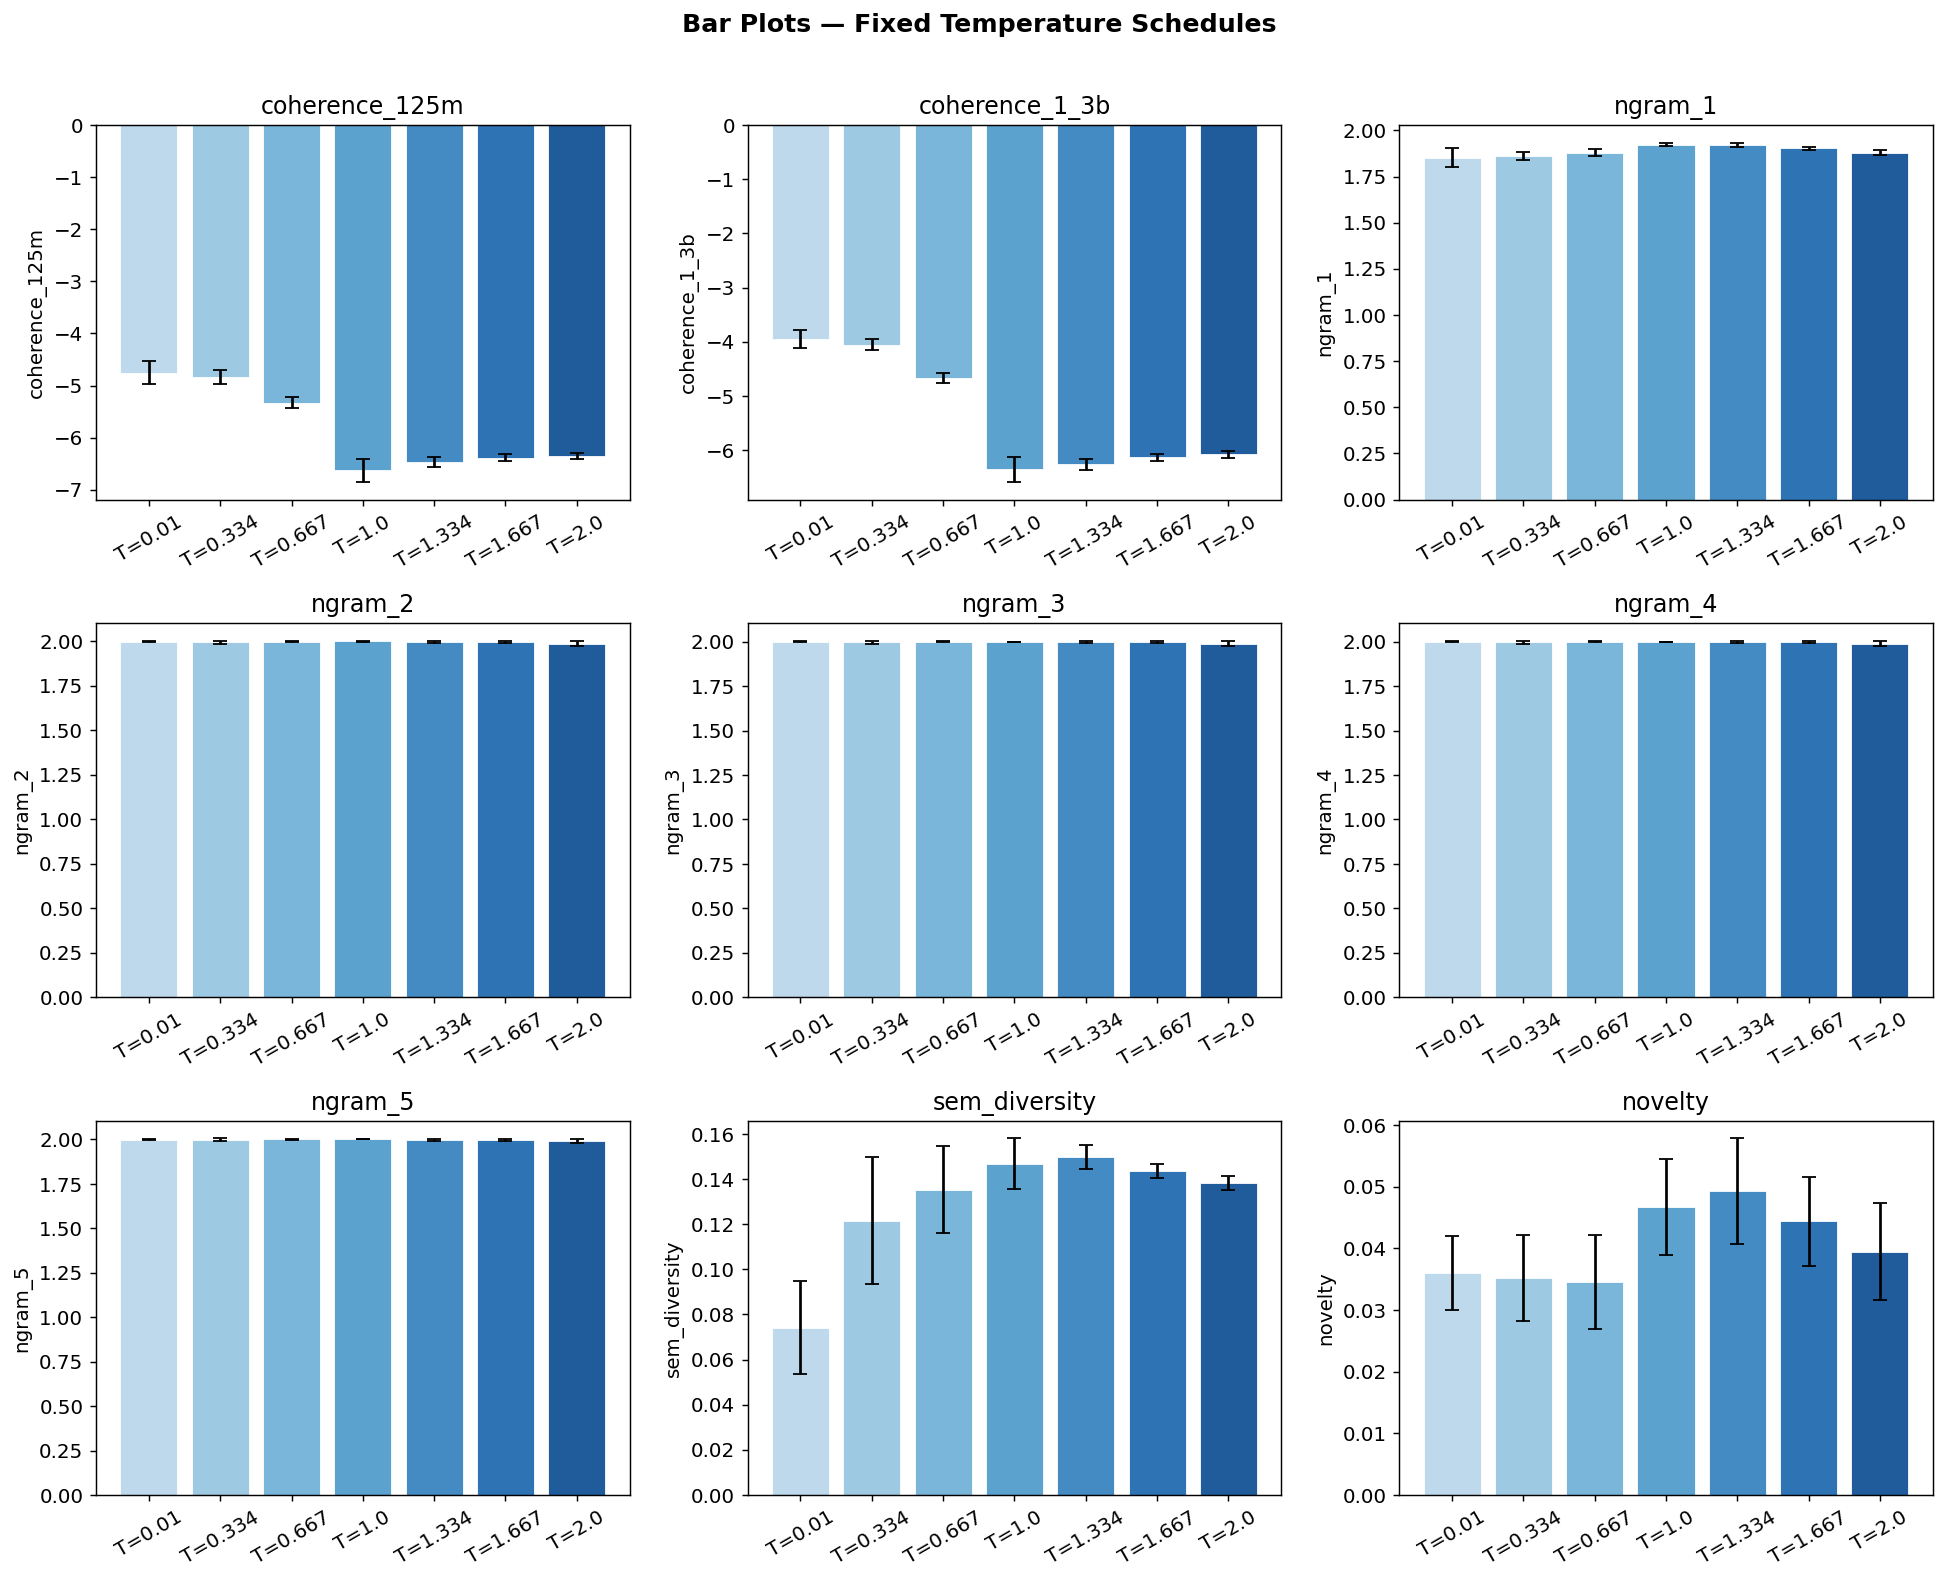

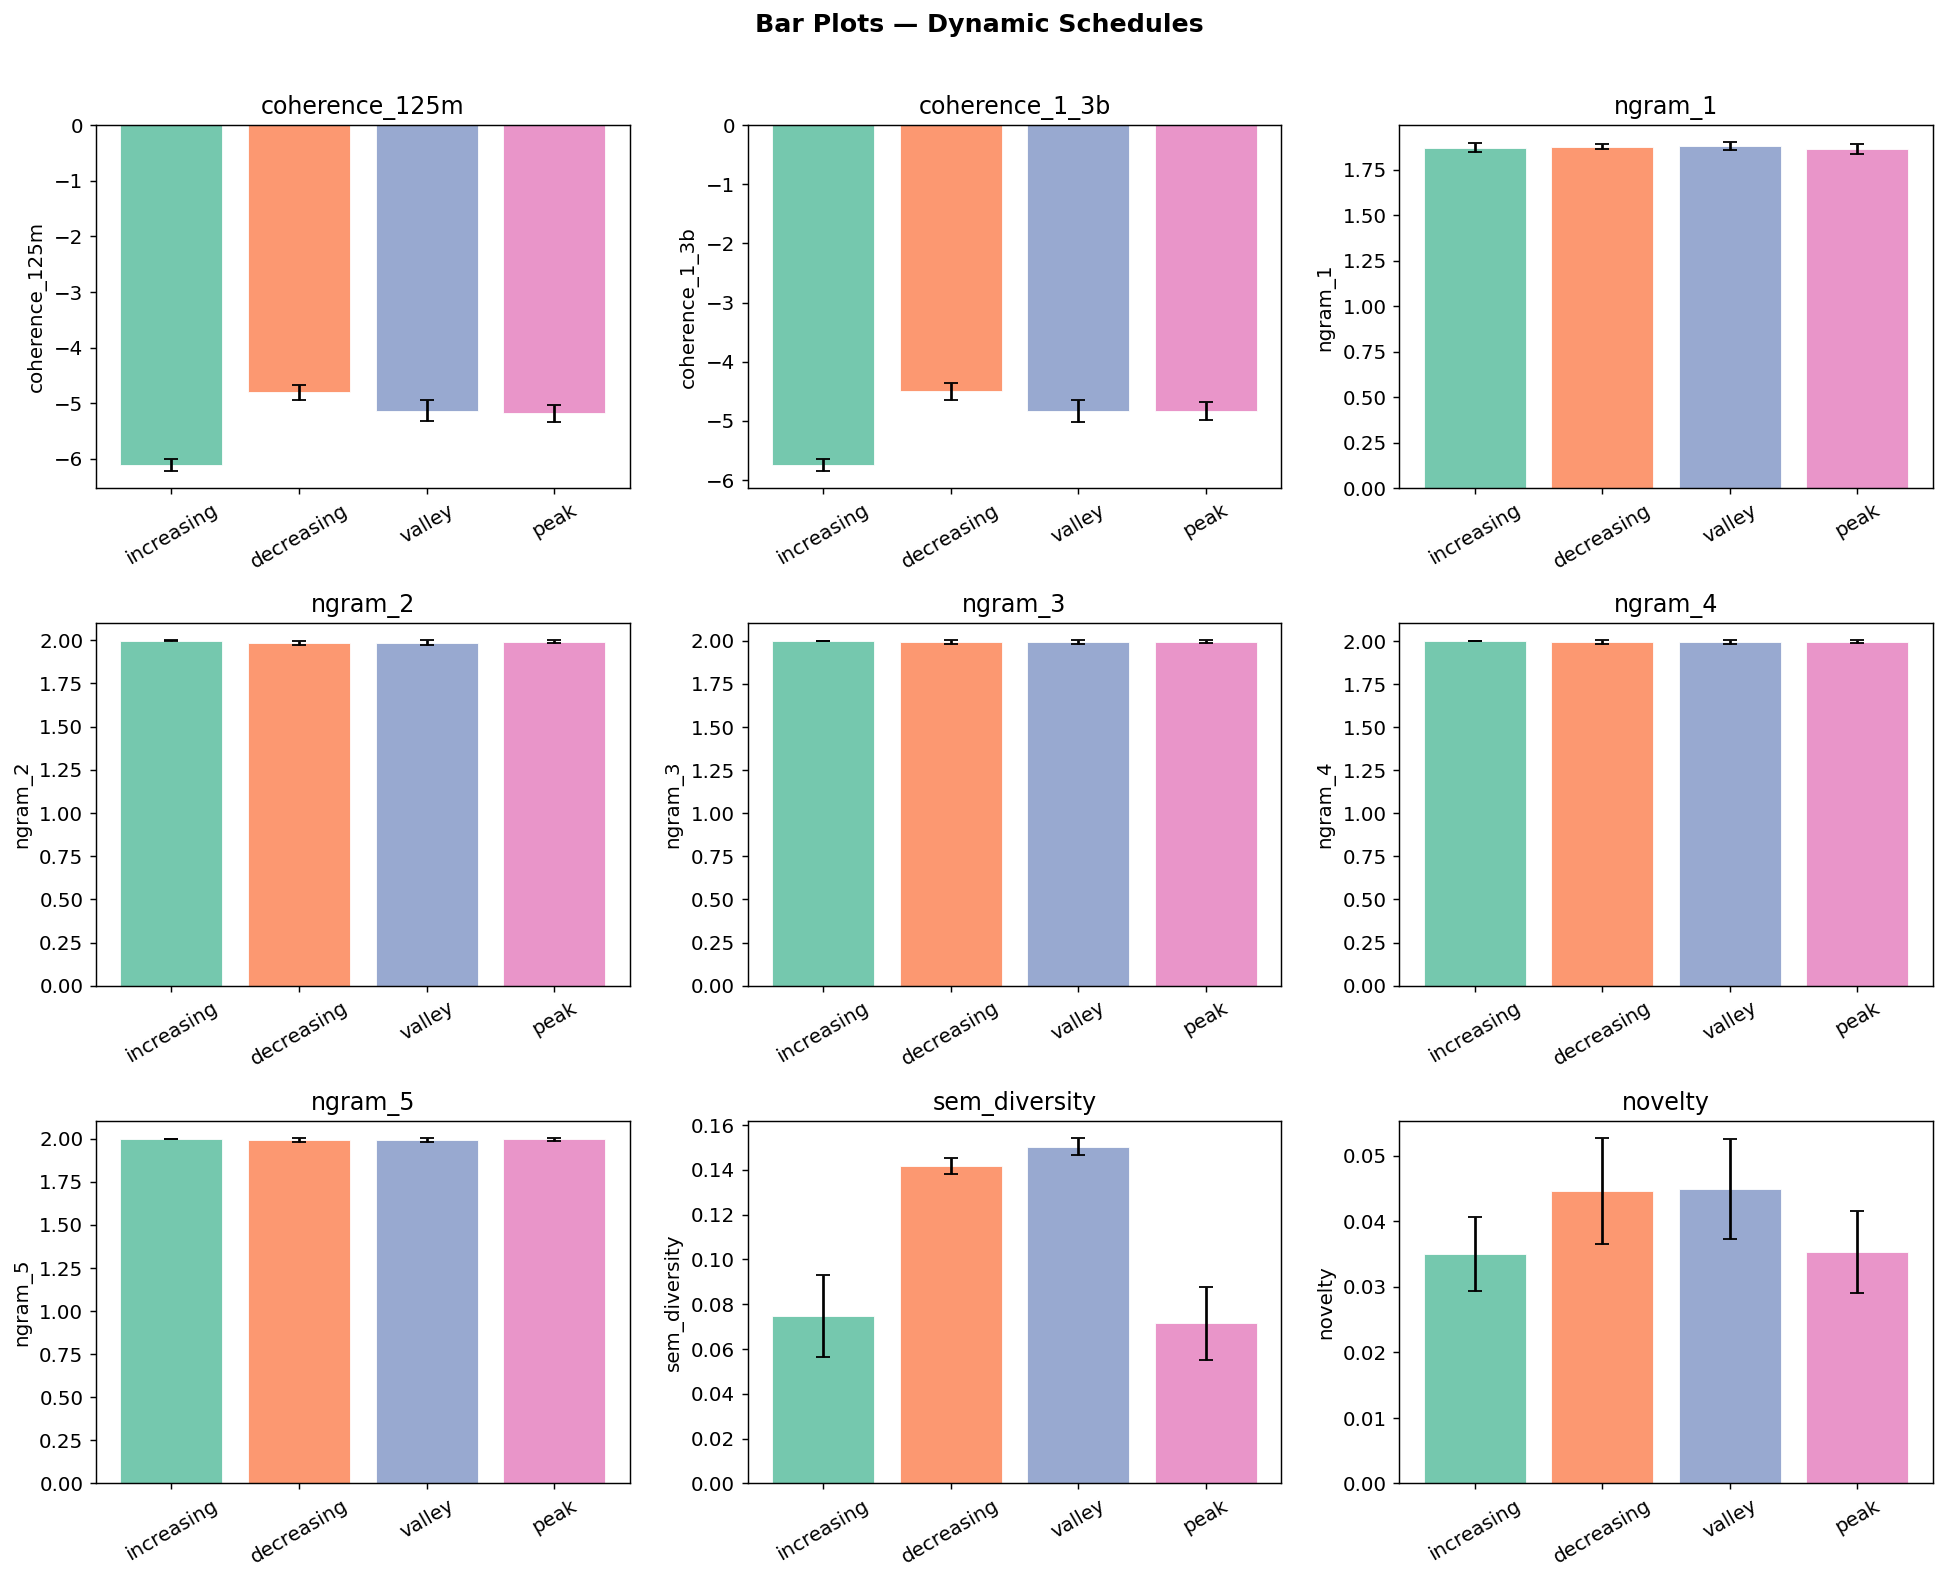

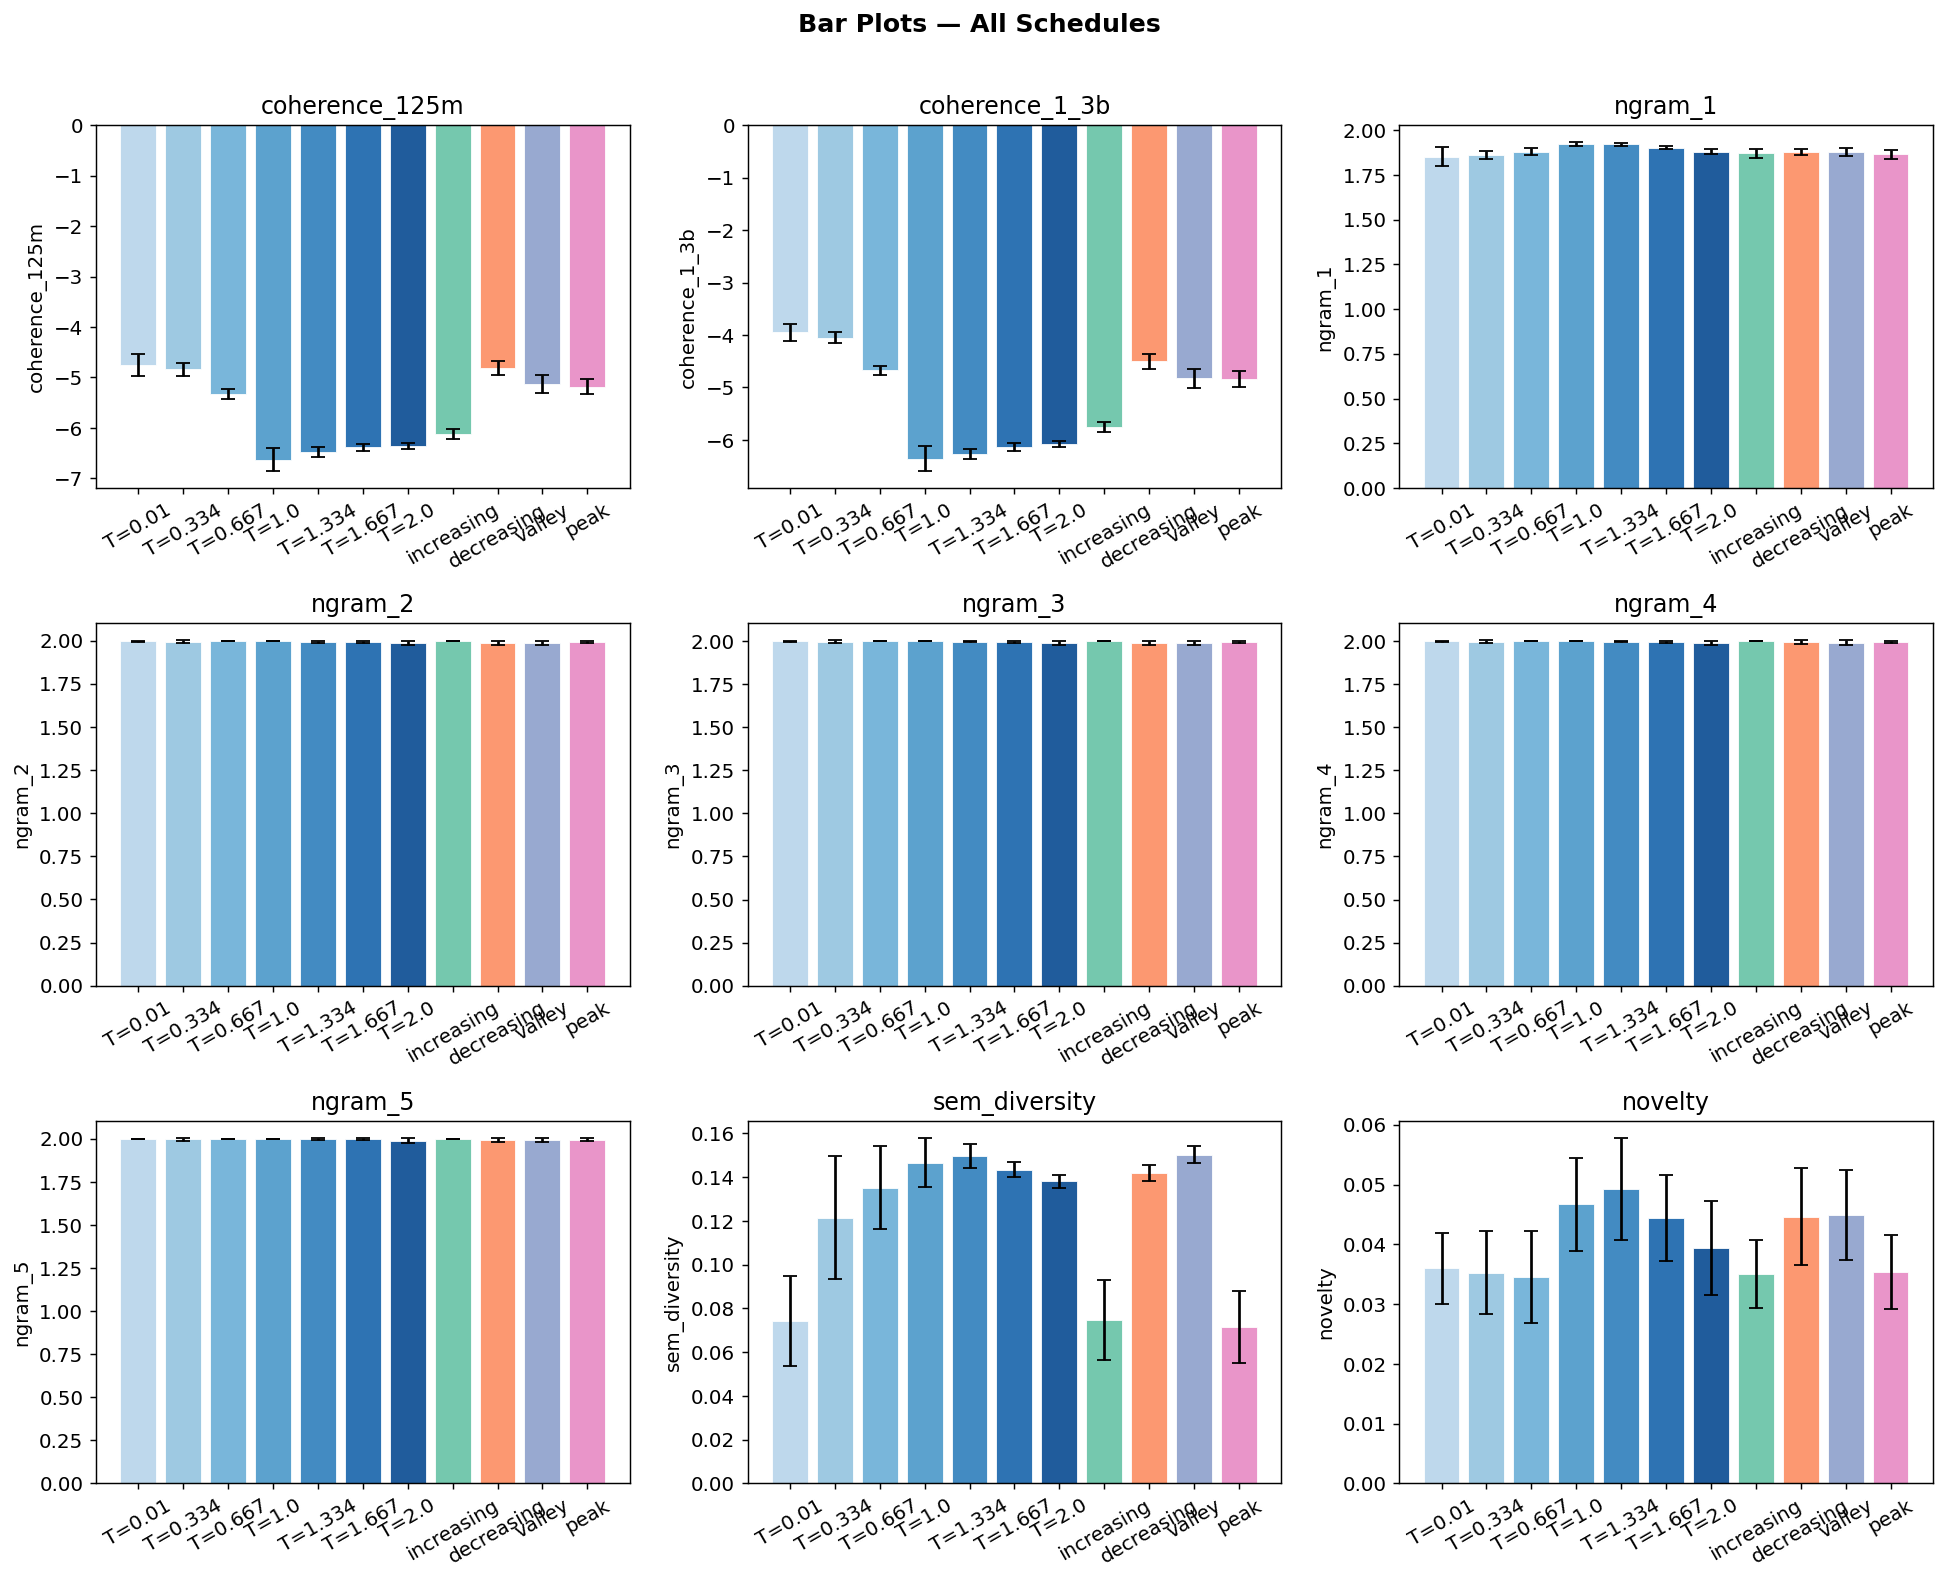

In [30]:
def bar_plot(metric: str, schedules: List[str], ax=None):
    """Bar plot with std error bars. Data = per-prompt means aggregated over prompts."""
    data   = df_prompt[df_prompt['schedule'].isin(schedules)]
    means  = data.groupby('schedule')[metric].mean().reindex(schedules)
    stds   = data.groupby('schedule')[metric].std().reindex(schedules)
    labels = [SCHED_LABELS[s] for s in schedules]
    colors = [COLOR_MAP[s] for s in schedules]
    if ax is None:
        _, ax = plt.subplots(figsize=(max(6, len(schedules) * 0.9), 4))
    ax.bar(labels, means.values, yerr=stds.values, capsize=4,
           color=colors, edgecolor='white', linewidth=0.5, alpha=0.9)
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=30)
    ax.set_ylabel(metric)
    return ax


def make_bar_grid(metrics, schedules, title):
    metrics = [m for m in metrics if m in df_prompt.columns]
    ncols = 3
    nrows = (len(metrics) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()
    for i, m in enumerate(metrics):
        bar_plot(m, schedules, ax=axes[i])
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


PLOT_METRICS    = [m for m in SUMMARY_METRICS if m in df_prompt.columns]
avail_fixed     = [s for s in FIXED_SCHEDULES   if s in AVAILABLE_SCHEDULES]
avail_dynamic   = [s for s in DYNAMIC_SCHEDULES if s in AVAILABLE_SCHEDULES]

make_bar_grid(PLOT_METRICS, avail_fixed,                  'Bar Plots — Fixed Temperature Schedules')
make_bar_grid(PLOT_METRICS, avail_dynamic,                'Bar Plots — Dynamic Schedules')
make_bar_grid(PLOT_METRICS, avail_fixed + avail_dynamic,  'Bar Plots — All Schedules')

## 7. Violin Plots

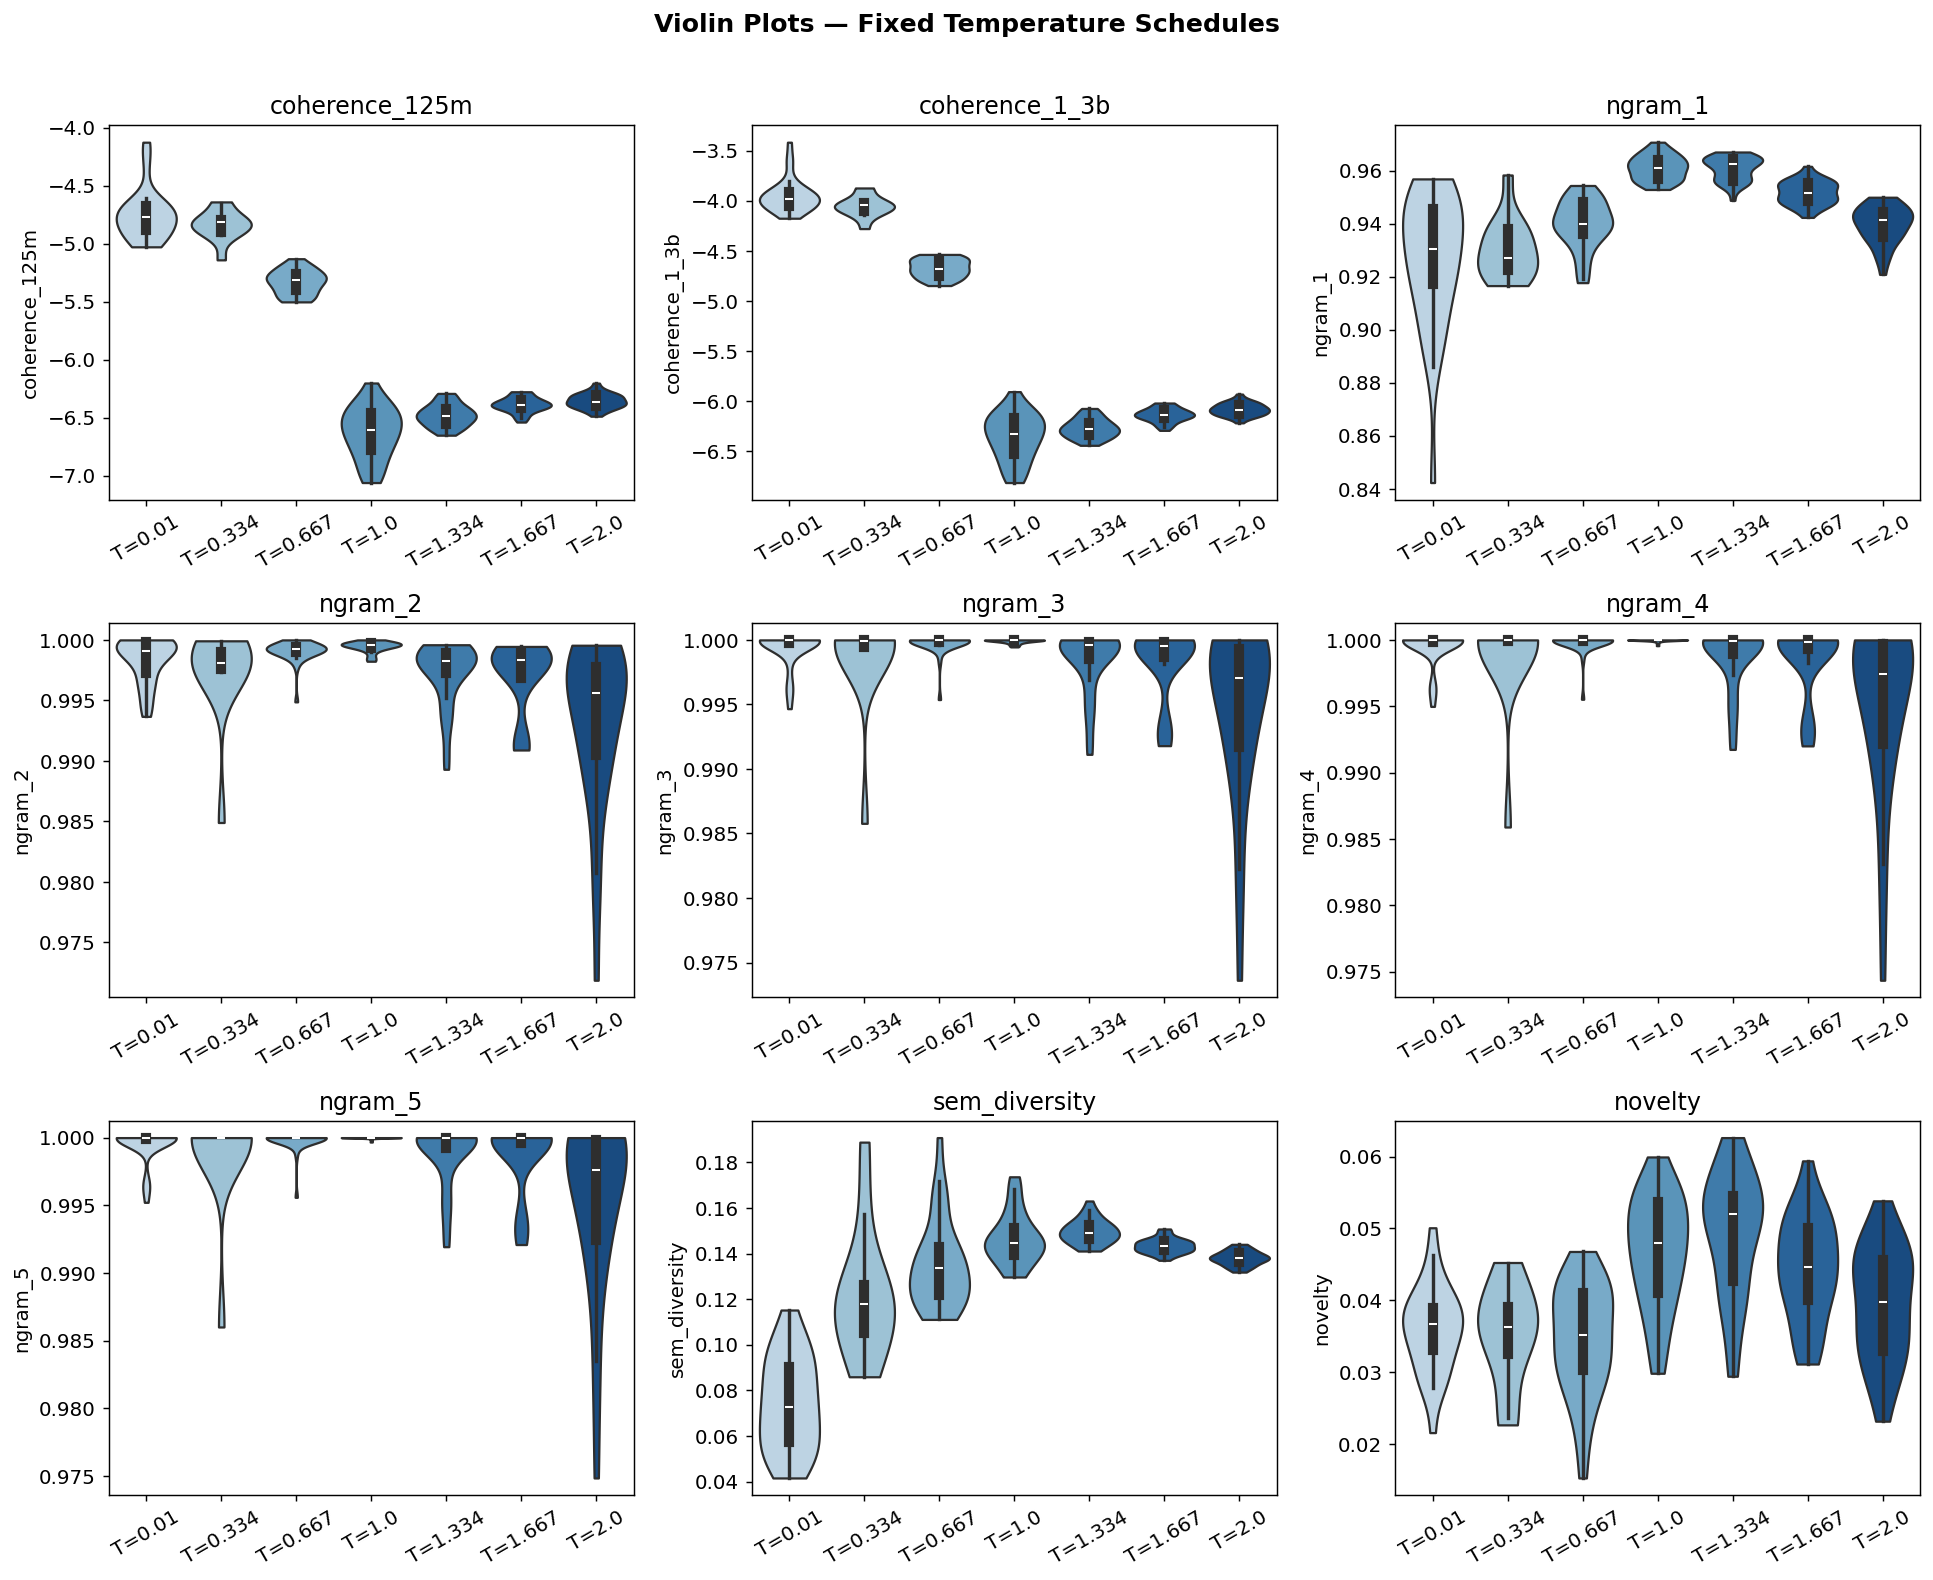

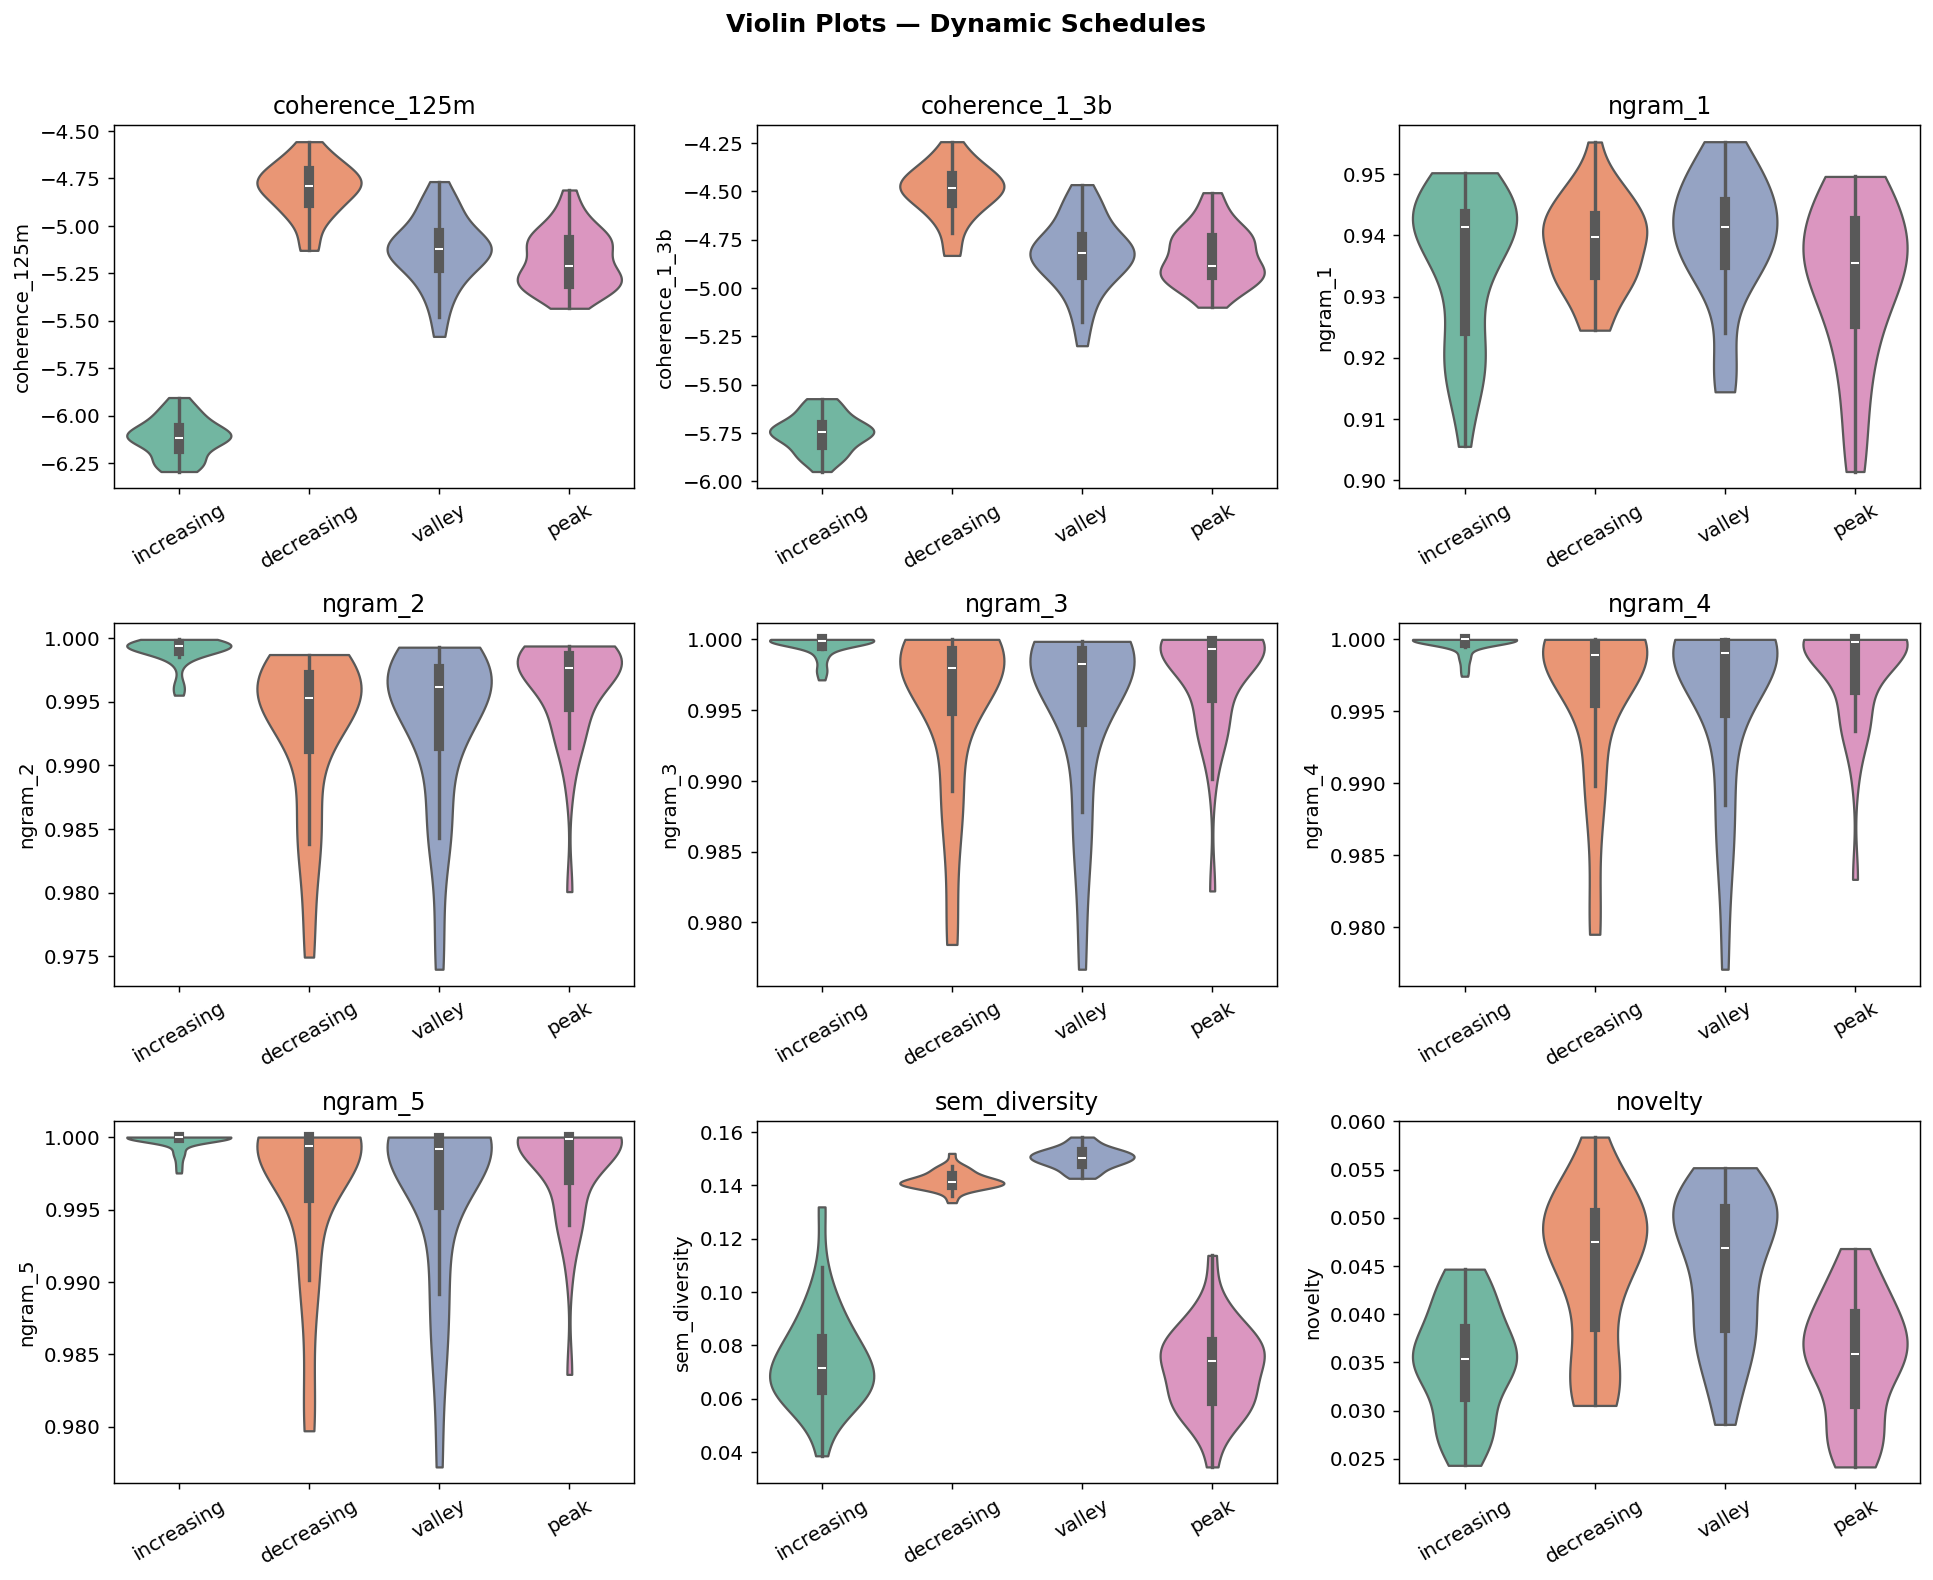

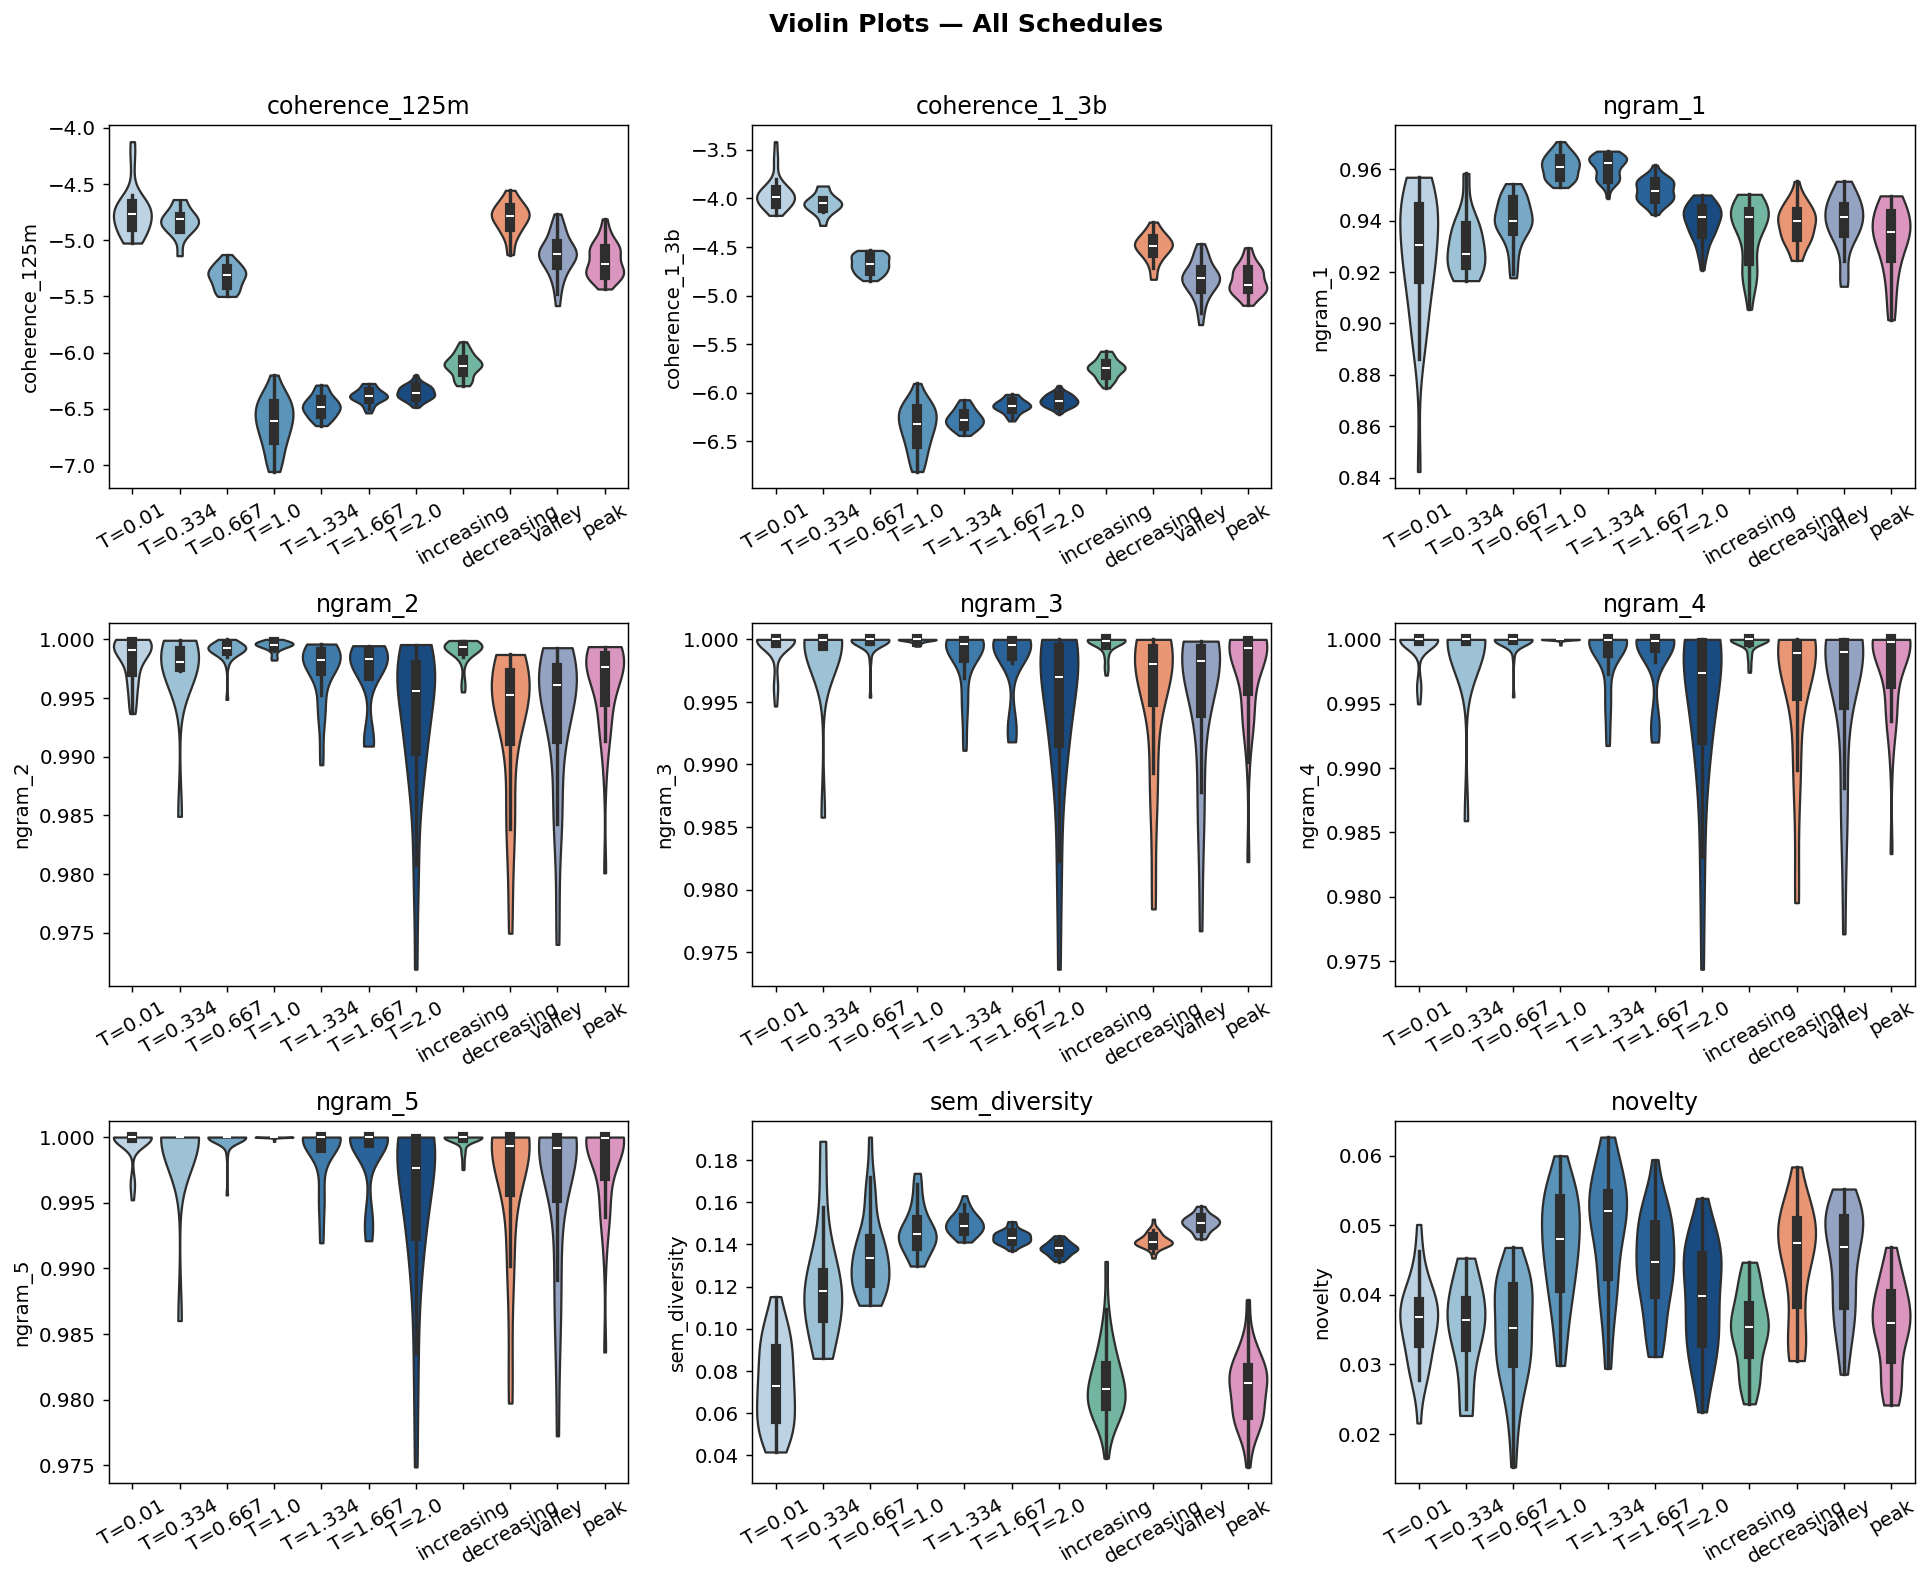

In [17]:
def make_violin_grid(metrics, schedules, title):
    """Violin plots showing full distribution across 30 prompts."""
    metrics = [m for m in metrics if m in df_prompt.columns]
    data    = df_prompt[df_prompt['schedule'].isin(schedules)].copy()
    data['label'] = data['schedule'].map(SCHED_LABELS)
    labels  = [SCHED_LABELS[s] for s in schedules]
    palette = {SCHED_LABELS[s]: COLOR_MAP[s] for s in schedules}

    ncols = 3
    nrows = (len(metrics) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4))
    axes = axes.flatten()
    for i, metric in enumerate(metrics):
        sns.violinplot(data=data, x='label', y=metric, order=labels,
                       palette=palette, inner='box', cut=0, ax=axes[i])
        axes[i].set_title(metric)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=30)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


make_violin_grid(PLOT_METRICS, avail_fixed,                  'Violin Plots — Fixed Temperature Schedules')
make_violin_grid(PLOT_METRICS, avail_dynamic,                'Violin Plots — Dynamic Schedules')
make_violin_grid(PLOT_METRICS, avail_fixed + avail_dynamic,  'Violin Plots — All Schedules')

## 8. N-gram Diversity — Continuous Plot

x = n-gram order (1..5), y = mean diversity.  One line per schedule, shaded band = ±1 std.
Shows how diversity collapses as n grows, and whether high-temperature schedules maintain diversity at higher n.

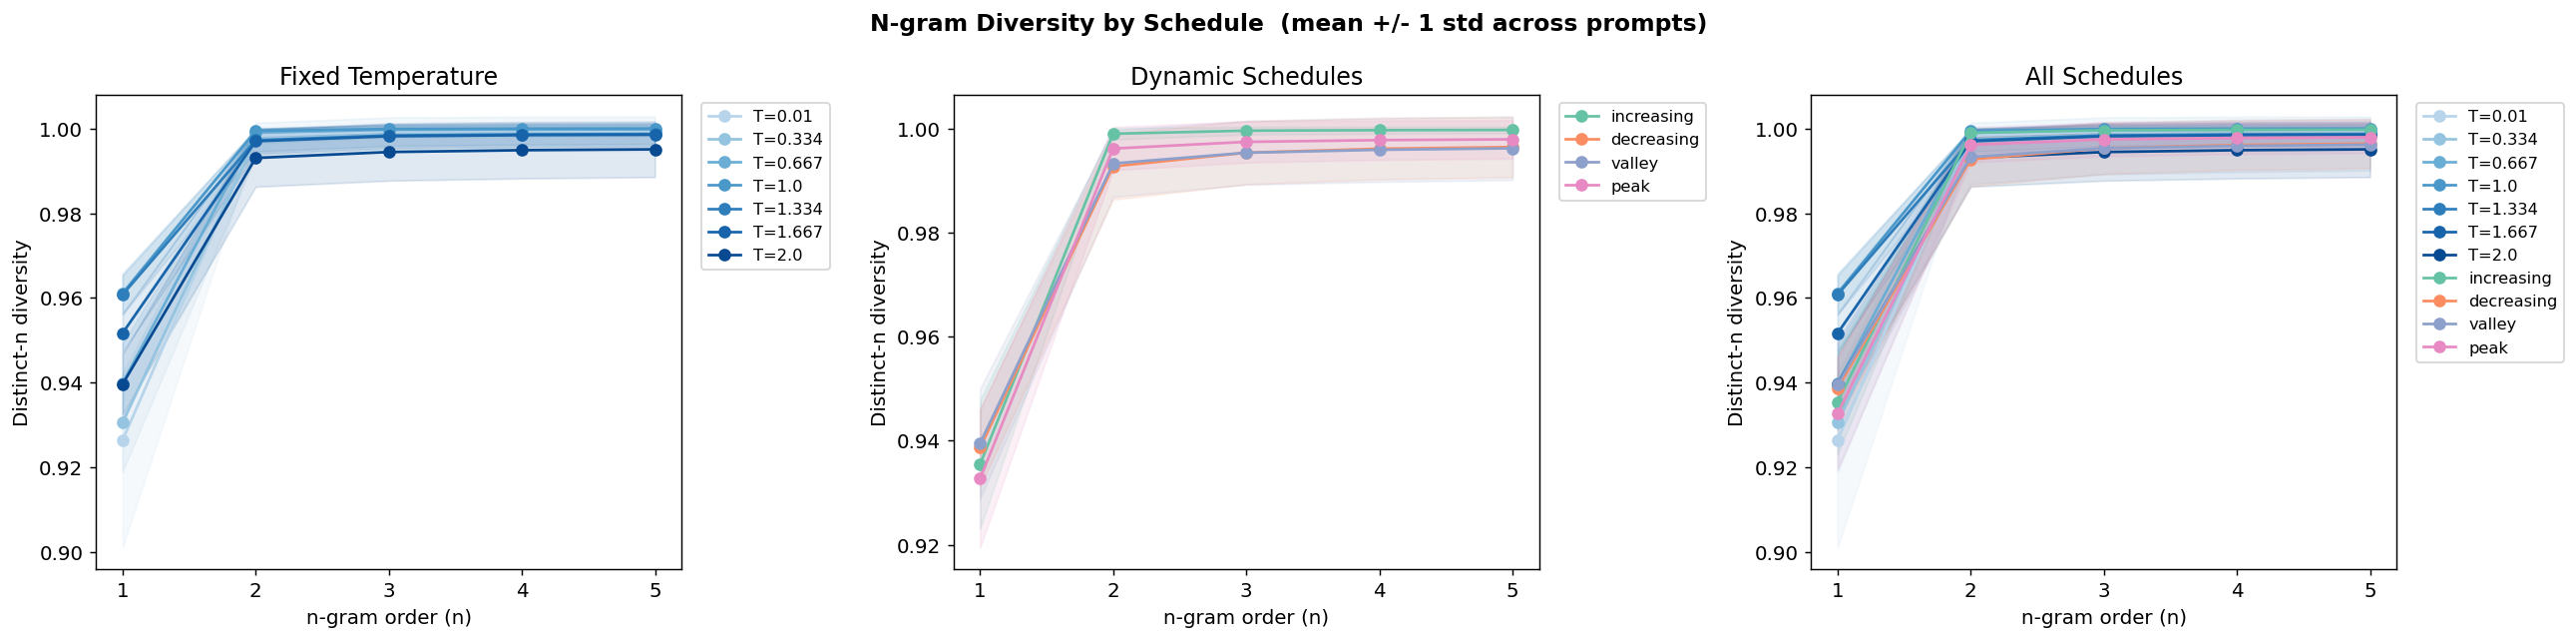

In [18]:
def ngram_continuous_plot(schedules: List[str], title: str, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    ns = list(range(1, 6))
    for sched in schedules:
        data  = df_prompt[df_prompt['schedule'] == sched]
        cols  = [f'ngram_{n}' for n in ns if f'ngram_{n}' in data.columns]
        means = data[cols].mean().values
        stds  = data[cols].std().values
        color = COLOR_MAP[sched]
        ax.plot(ns[:len(means)], means, marker='o', label=SCHED_LABELS[sched], color=color)
        ax.fill_between(ns[:len(means)], means - stds, means + stds,
                        alpha=0.12, color=color)
    ax.set_xlabel('n-gram order (n)')
    ax.set_ylabel('Distinct-n diversity')
    ax.set_xticks(ns)
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    return ax


fig, axes = plt.subplots(1, 3, figsize=(20, 5))
ngram_continuous_plot(avail_fixed,                'Fixed Temperature',    ax=axes[0])
ngram_continuous_plot(avail_dynamic,              'Dynamic Schedules',    ax=axes[1])
ngram_continuous_plot(avail_fixed + avail_dynamic, 'All Schedules',       ax=axes[2])
plt.suptitle('N-gram Diversity by Schedule  (mean +/- 1 std across prompts)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Coherence Detail

OPT-125M vs OPT-1.3B.  Higher (less negative) = more coherent.

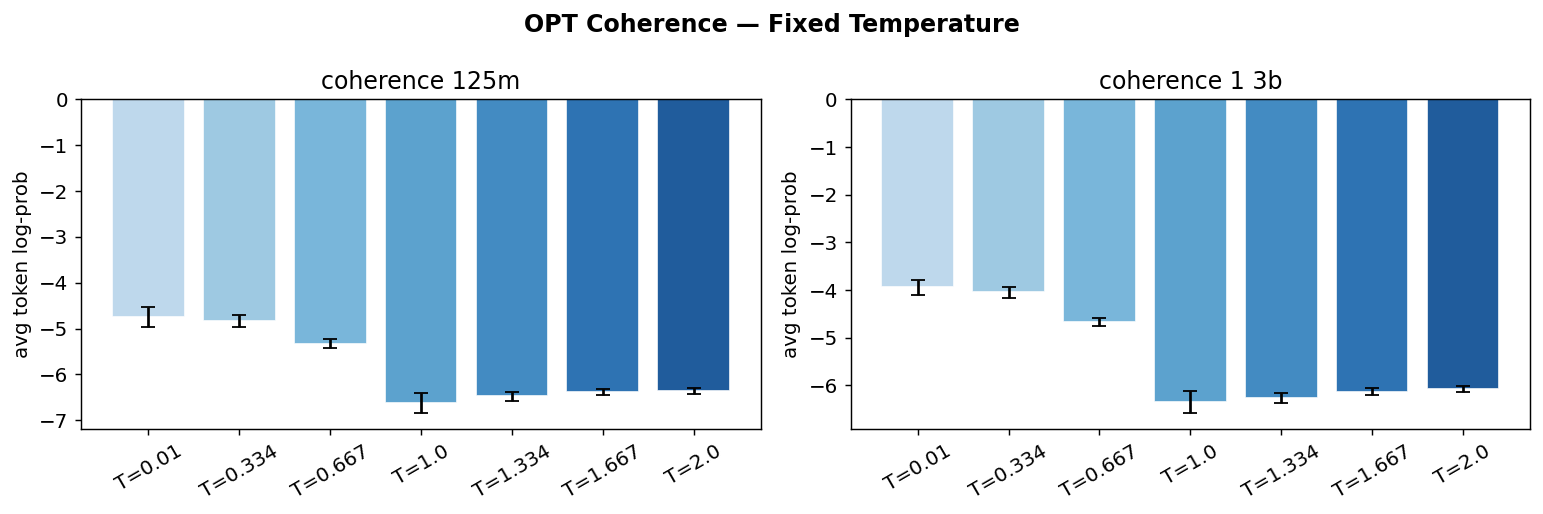

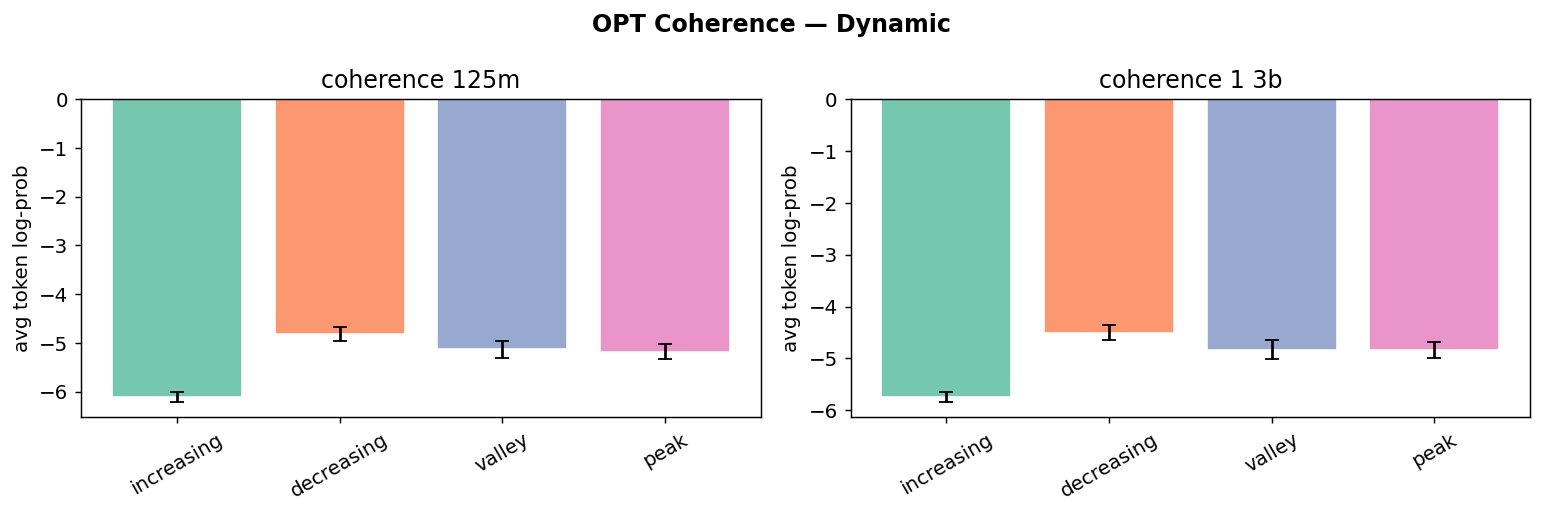

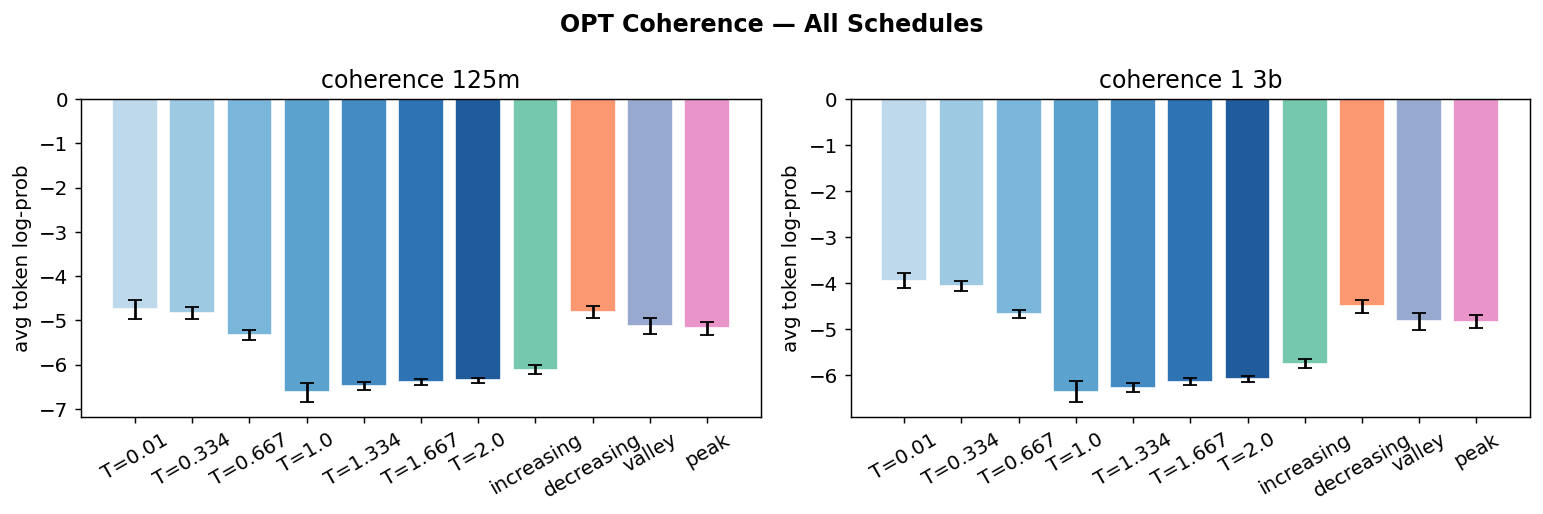

In [19]:
coh_cols = [c for c in ('coherence_125m', 'coherence_1_3b') if c in df_prompt.columns]

if not coh_cols:
    print('No coherence columns found — run evaluate_final_coherence.slurm first.')
else:
    for group_scheds, group_title in [
        (avail_fixed,                'Fixed Temperature'),
        (avail_dynamic,              'Dynamic'),
        (avail_fixed + avail_dynamic, 'All Schedules'),
    ]:
        data    = df_prompt[df_prompt['schedule'].isin(group_scheds)].copy()
        data['label'] = data['schedule'].map(SCHED_LABELS)
        labels  = [SCHED_LABELS[s] for s in group_scheds]
        palette = {SCHED_LABELS[s]: COLOR_MAP[s] for s in group_scheds}

        fig, axes = plt.subplots(1, len(coh_cols), figsize=(6 * len(coh_cols), 4), squeeze=False)
        for ax, col in zip(axes[0], coh_cols):
            means = data.groupby('label')[col].mean().reindex(labels)
            stds  = data.groupby('label')[col].std().reindex(labels)
            ax.bar(labels, means.values, yerr=stds.values, capsize=4,
                   color=[palette[l] for l in labels], alpha=0.9, edgecolor='white')
            ax.set_title(col.replace('_', ' '))
            ax.tick_params(axis='x', rotation=30)
            ax.set_ylabel('avg token log-prob')
        fig.suptitle(f'OPT Coherence — {group_title}', fontweight='bold')
        plt.tight_layout()
        plt.show()

## References

- Ismaylzade, M. et al. (2024). *Creative Story Generation* — [github.com/mismayil/creative-story-gen](https://github.com/mismayil/creative-story-gen)
- Karampiperis, P. et al. (2014). *Towards Computational Creativity Metrics.*
- Padmakumar, V. & He, H. (2023). *Does Collaborative Human–LM Dialogue Generation Help LMs Produce Better Stories?*
- Su, H. & Collier, N. (2022). *Contrastive Search Is What You Need For Neural Text Generation.*
- Flesch, R. (1940). *Marks of Readable Style: A Study in Adult Education.*
- Li, J. et al. (2016). *A Diversity-Promoting Objective Function for Neural Conversation Models.*